# Debugging summary (see chat for full derivation)

Six distinct issues were found and fixed/diagnosed in this notebook, layered on
top of each other. **Fix #6's fit result is UNVALIDATED** - the kernel crashed
before it printed output; the cell right before it (a cheap, s2fft-free linear-
algebra sanity check) should be run first on a freshly-restarted kernel.

1. **`numpyro.infer.MCMC`/`NUTS` were imported but never instantiated anywhere.**
   The final cell crashed with `NameError: name 'mcmc' is not defined`. Everything
   labeled "MCMC Best-Fit..." in the original notebook was actually produced by
   `jaxopt.LBFGS` (a point optimizer), not a posterior sampler.

2. **Missing SVD singular-value weighting.** `s_svd` was computed but never used -
   `mode_tensor` was built from unit-norm `u_svd`/`v_svd` alone, forcing absurd
   coefficients (`p ~ O(100)`) to represent a modest 10% perturbation. Fixed by
   scaling `v_slice` by `s_svd`.

3. **Stale visibility normalization.** `y_true` is generated using `norms_TRUE`.
   Every calibration forward model instead divided by `norms_PERTURBED` - a
   snapshot of the *original* beam's power, frozen before calibration starts and
   never recomputed as the beam estimate changes. Fixed via `compute_norms_curr()`,
   which recomputes total power from the current beam on every evaluation.

4. **Structural sky/beam degeneracy (Iterated Conditional Modes).** The alternating
   loop fully re-solves the sky before every beam step; with far more sky degrees
   of freedom than beam parameters, the sky absorbs nearly everything explainable
   on round 1. A damped-step variant is included as a comparison (damps the STEP
   toward a fully-converged sky solve, not the solve's accuracy itself - an
   earlier version that truncated CG instead of damping the step diverged badly).

5. **Near-degeneracy among modes 0-2 in visibility space**, discovered after
   fixes #1-3 still left 3 of 5 components stuck near zero (or wrong-signed)
   across LBFGS, NUTS, clipped-sky, and raw-sky fits, despite those modes having
   the *highest* raw sensitivity of all 5. The mode Gram matrix showed pairwise
   cosine similarity up to -0.95 and a condition number of ~5,400 - the data
   constrains combinations of modes 0-2 tightly, not their individual values.
   A naive rotation into the Gram matrix's eigenbasis (without whitening) made
   things far worse, because the eigenvalues still spanned ~5,400x in scale and
   LBFGS's step heuristics aren't built for that. The corrected version below
   both rotates AND whitens (divides by sqrt of the noise-weighted Fisher
   eigenvalues), using the true chi2 curvature (with `1/Ndiag` weighting), not
   the earlier un-weighted Gram matrix.

6. **A `jaxopt.LBFGS` recompilation bug**, found last but likely responsible for
   most of the kernel crashes throughout this session: `optimize_beam_step`
   built a brand-new closure and a brand-new `jaxopt.LBFGS` instance on every
   single call. JAX compiles keyed to function-object identity, so this forced a
   fresh compile every iteration, of every loop, in every cell, all session -
   with old compiled programs never evicted. Fixed by building the loss function
   and the `LBFGS` solver ONCE at module scope, passing what used to be closure
   captures as explicit runtime arguments instead.

7. **Single-frequency data cannot disambiguate a spurious beam-error fit from
   the true one.** After fixes #1-6, LBFGS/NUTS reproducibly converged to a
   confident, well-conditioned, WRONG answer (~-0.99 cosine-anti-aligned with
   the true correction, with a genuine finite chi2 minimum ~50-70x past where
   the prior had been letting the fit stop). Root cause: the 20 "pointings"
   are rotations of one physical beam - total power (and hence norms_curr) is
   rotation-invariant, so all 20 give near-identical information w.r.t. this
   particular failure mode, and a coincidental fit at one frequency has no
   reason to fail at another. FREQ_START/FREQ_END is widened below (fix #7)
   so the same 5 coefficients must explain multiple frequencies' visibilities
   jointly - something a coincidental single-frequency fit has no reason to
   also satisfy, unlike a real, frequency-smooth beam defect.

8. **Sky/beam frequency-index misalignment.** `gsm_model.npy` (50 channels)
   is offset by -1 relative to `bowtie`/`vivaldi` (202/201 channels) -
   `gsm_model[i]` corresponds to `bowtie`/`vivaldi` index `i+1`, and
   `bowtie`'s extra channel is at the end. `load_true_sky()` now applies this
   offset explicitly. This was silently present even in the original
   single-channel run (harmless there, since one frequency-independent
   channel can't expose a frequency-alignment bug), but would have
   undermined fix #7's entire premise - the multi-frequency test only works
   if sky and beam are evaluated at genuinely corresponding frequencies.

9. **Both alternating loops now track the best-seen (lowest-loss) point**,
   not just whatever iteration happens to run last. Both loops have shown a
   pattern of a good, oracle-like answer partway through, followed by a jump
   to a much larger, spurious point in a later round (same mechanism as the
   unbounded-objective issue found in the single-frequency investigation).
   Best-seen tracking makes a run - and even a mid-run crash - still yield a
   usable answer without needing every iteration to behave, and checkpoints
   to /tmp so a crash loses at most the current iteration.

Two additional diagnostics (not fixes) were added on request, both using only
the original, uncalibrated Wiener filter (no beam correction, p=0), to test two
specific hypotheses about the pre-calibration reconstruction quality:
- Single pointing vs. all 20, to check for inter-pointing smearing.
- A perturbation-scale sweep (alpha from 0 to 1, interpolated in alm-space
  between the true and perturbed beam) to check whether reconstruction
  quality degrades smoothly or has a sharp breakdown threshold.
A quick sanity check is included first, since the perturbation's power-
conservation rescale (cell 3) may be canceling most of the intended 10%
amplitude component algebraically, leaving mostly a phase-only error -
worth confirming numerically rather than assuming either way.

Diagnostic and comparison cells from the debugging process are included alongside
the corrected pipeline so the reasoning is reproducible, not just the fix.


In [1]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update(
    "jax_platform_name", "cpu"
)  # Change to "gpu" if running on a cluster
import jax.numpy as jnp
import jax.scipy.sparse.linalg as jsp_linalg
import jaxopt

print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX devices: [CpuDevice(id=0)]
Default backend: cpu


In [2]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial
import itertools
import time

import astropy
import astropy.units as u
import corner  # pip install corner (for the posterior plots)
import croissant as cro
import croissant.jax as crojax
import healpy as hp
import lunarsky
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from healpy import Alm, get_nside, projview, ud_grade
from numpyro.infer import MCMC, NUTS
import s2fft
from tqdm.notebook import tqdm

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [3]:
def create_perturbed_base_map(
    base_pixel_map, lmax, nside, amp_scale=1.10, phase_shift_deg=5.0
):
  """Takes a 1D pixel map, converts it to 2D s2fft ALMs, applies a

  consistent phase/amplitude perturbation, and returns the modified pixel map.
  """
  # Forward SHT to get into 2D s2fft ALM space
  beam2alm = partial(
      s2fft.forward_jax,
      L=lmax + 1,
      spin=0,
      nside=nside,
      sampling="healpix",
      reality=True,
  )
  clean_alms = beam2alm(jnp.array(base_pixel_map))

  # Apply the complex phase and amplitude shift
  phase_rad = np.radians(phase_shift_deg)
  perturbation_factor = amp_scale * np.exp(1j * phase_rad)
  perturbed_alms = clean_alms * perturbation_factor

  # Inverse SHT to turn it back into a valid HEALPix pixel map
  alm2beam = partial(
      s2fft.inverse_jax,
      L=lmax + 1,
      spin=0,
      nside=nside,
      sampling="healpix",
      reality=True,
  )
  perturbed_map = alm2beam(perturbed_alms).real

  return np.asarray(perturbed_map)


def rotate_bowtie(bowtie_beam, elaz):
  el, az = elaz
  angle_1 = (0, 0, el)
  angle_2 = (az, 0, 0)
  rotator_1 = hp.rotator.Rotator(rot=angle_1)
  rotator_2 = hp.rotator.Rotator(rot=angle_2)
  rotator = rotator_1 * rotator_2
  rotated_bowtie_beam = np.empty(bowtie_beam.shape)
  for i, beam in enumerate(bowtie_beam):
    rotated_bowtie_beam[i] = rotator.rotate_map_alms(beam)
  return rotated_bowtie_beam


# Load Beams
bowtie = np.load("eigsep_bowtie_v000.npz")
vivaldi = np.load("eigsep_vivaldi.npz")

# --- FIX #7: check how many frequency channels are actually available ---
# before committing to a range. The SVD below runs on the FULL bowtie["bm"]
# (all channels) regardless of FREQ_START/FREQ_END, so widening the range
# below does NOT require recomputing it.
print(f"bowtie['bm'] shape (n_freq_total, npix): {bowtie['bm'].shape}")
print(f"vivaldi['freqs'] shape: {vivaldi['freqs'].shape}")
try:
  _gsm_shape_check = np.load("gsm_model.npy").shape
  print(f"gsm_model.npy shape (n_freq_total, npix): {_gsm_shape_check}")
except Exception as _e:
  print(f"(could not pre-check gsm_model.npy shape: {_e})")

# SVD the bowtie beam (full_matrices=False saves ~19 GB of RAM!)
u_svd, s_svd, v_svd = np.linalg.svd(bowtie["bm"], full_matrices=False)
print(f"SVD computed safely! U shape: {u_svd.shape}, V shape: {v_svd.shape}")

# Frequency Indices
# FIX #7: widened from a single channel (was FREQ_START=6, FREQ_END=7) so
# the same 5 beam-error coefficients must explain MULTIPLE frequencies'
# visibilities jointly - a coincidental single-frequency fit has no reason
# to also satisfy a second, independently-generated frequency's data, while
# a real beam defect (frequency-smooth) should. ADJUST THESE two numbers
# based on the shapes printed just above - this default (8 channels
# centered near the original single channel) is a starting guess, not a
# verified-safe range for your actual data.
FREQ_START = 2
FREQ_END = 10
N_FREQS = FREQ_END - FREQ_START
freq = vivaldi["freqs"][FREQ_START:FREQ_END]
nside = vivaldi["nside"].item()
lmax = 2 * nside
npix = bowtie["bm"].shape[-1]

# --- CREATE THE PERTURBED BASE MAP WITH POWER CONSERVATION ---
base_bowtie_multi_TRUE = bowtie["bm"][FREQ_START:FREQ_END]
base_bowtie_multi_PERTURBED = np.zeros_like(base_bowtie_multi_TRUE)

# We need the true total power to anchor our normalization
beam2alm = partial(
    s2fft.forward_jax,
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
)

for f in range(N_FREQS):
  # 1. Calculate the total power (norm) of the clean base beam
  clean_alms = beam2alm(jnp.array(base_bowtie_multi_TRUE[f]))
  true_power = crojax.alm.total_power(clean_alms, lmax)

  # 2. Generate the raw perturbed map (introduces the 5-degree phase warp)
  raw_perturbed_map = create_perturbed_base_map(
      base_bowtie_multi_TRUE[f],
      lmax,
      nside,
      amp_scale=1.10,  # Keeps your 10% amplitude structure
      phase_shift_deg=5.0,  # Keeps your 5-degree phase distortion
  )

  # 3. Calculate the power of this new perturbed map
  perturbed_alms_raw = beam2alm(jnp.array(raw_perturbed_map))
  perturbed_power_raw = crojax.alm.total_power(perturbed_alms_raw, lmax)

  # 4. Enforce power conservation!
  # Scale the map so its total integrated power exactly matches the true universe beam
  u_scale = jnp.sqrt(true_power / perturbed_power_raw)
  base_bowtie_multi_PERTURBED[f] = raw_perturbed_map * u_scale

print("Power-conserving perturbed base beam created successfully!")

bowtie['bm'] shape (n_freq_total, npix): (202, 49152)
vivaldi['freqs'] shape: (201,)
gsm_model.npy shape (n_freq_total, npix): (50, 49152)
SVD computed safely! U shape: (202, 202), V shape: (202, 49152)
Power-conserving perturbed base beam created successfully!


In [4]:
# --- ROTATE BOTH THROUGH THE 20 POINTINGS ---
elaz_pointings = [(float(el), 0.0) for el in np.linspace(0, 90, 20)]

rotated_bowties_TRUE = []
rotated_bowties_PERTURBED = []

for elaz in tqdm(elaz_pointings, desc="Rotating beams"):
  # 1. Rotate the clean base beam across all 20 pointings
  rotated_bowties_TRUE.append(rotate_bowtie(base_bowtie_multi_TRUE, elaz))

  # 2. Rotate the flawed base beam across the exact same 20 pointings
  # Every single pointing now inherits the exact same physical distortion!
  rotated_bowties_PERTURBED.append(
      rotate_bowtie(base_bowtie_multi_PERTURBED, elaz)
  )

# Combine and mask the back-lobes (npix//2)
beams_true_f = jnp.array(np.stack(rotated_bowties_TRUE)).at[..., npix // 2 :].set(0)
beams_pert_f = jnp.array(np.stack(rotated_bowties_PERTURBED)).at[..., npix // 2 :].set(0)

# --- FINAL STEP: RUN SHT TO GET YOUR DOWNSTREAM ARRAYS ---
beam_alms_TRUE = []
beam_alms_PERTURBED = []
norms_TRUE = []
norms_PERTURBED = []

beam2alm = partial(
    s2fft.forward_jax,
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
)

for b_idx in tqdm(range(beams_true_f.shape[0]), desc="Final SHT on Beams"):
  # SHT and Norms on True (for generating y_true data)
  alm_t = jax.vmap(beam2alm)(beams_true_f[b_idx])
  norm_t = jax.vmap(lambda x: crojax.alm.total_power(x, lmax))(alm_t)

  # SHT and Norms on Perturbed (for your Wiener Filter / MCMC guesses)
  alm_p = jax.vmap(beam2alm)(beams_pert_f[b_idx])
  norm_p = jax.vmap(lambda x: crojax.alm.total_power(x, lmax))(alm_p)

  beam_alms_TRUE.append(alm_t)
  beam_alms_PERTURBED.append(alm_p)
  norms_TRUE.append(norm_t)
  norms_PERTURBED.append(norm_p)

# Convert to final JAX Tensors
beam_alms_TRUE = jnp.array(beam_alms_TRUE)  # Shape: (B, F, L, M)
beam_alms_PERTURBED = jnp.array(beam_alms_PERTURBED)  # Shape: (B, F, L, M)
norms_TRUE = jnp.array(norms_TRUE)  # Shape: (B, F)
norms_PERTURBED = jnp.array(norms_PERTURBED)  # Shape: (B, F)

Rotating beams:   0%|          | 0/20 [00:00<?, ?it/s]

Final SHT on Beams:   0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
ntimes = 500
world = "earth"

dt_sim = cro.constants.sidereal_day[world] / ntimes
phases = crojax.simulator.rot_alm_z(lmax, ntimes, dt_sim, world=world)

time_obs = astropy.time.Time("2025-12-01 09:00:00")
loc = astropy.coordinates.EarthLocation(lat=39.2477, lon=-113.4033)
topo = astropy.coordinates.AltAz(obstime=time_obs, location=loc)

eul_topo, dl_topo = crojax.rotations.generate_euler_dl(lmax, topo, "fk5")
eul_gal, dl_gal = crojax.rotations.generate_euler_dl(lmax, "galactic", "fk5")

topo2fk5 = partial(
    s2fft.utils.rotation.rotate_flms,
    L=lmax + 1,
    rotation=eul_topo,
    dl_array=dl_topo,
)
gal2fk5 = partial(
    s2fft.utils.rotation.rotate_flms,
    L=lmax + 1,
    rotation=eul_gal,
    dl_array=dl_gal,
)


def load_true_sky(realistic=False):
  sky_L = lmax + 1
  sky_nside = sky_L // 2
  if realistic:
    # --- FIX #8: gsm_model.npy is offset by -1 relative to bowtie/vivaldi's
    # frequency indexing (gsm_model[0] corresponds to bowtie/vivaldi index 1;
    # bowtie has one extra channel at the END that vivaldi/gsm_model don't
    # have). Without this offset, the sky and beam at "the same" FREQ_START:
    # FREQ_END index actually come from ADJACENT, not matching, physical
    # frequencies - which would undermine the multi-frequency degeneracy
    # test specifically (it relies on sky and beam being evaluated at truly
    # corresponding frequencies to expose their different spectral behavior).
    GSM_FREQ_START = FREQ_START - 1
    GSM_FREQ_END = FREQ_END - 1
    if GSM_FREQ_START < 0:
      raise ValueError(
          f"FREQ_START={FREQ_START} has no gsm_model.npy counterpart "
          f"(would need index {GSM_FREQ_START} < 0) - bowtie/vivaldi index 0 "
          f"has no matching sky channel. Use FREQ_START >= 1."
      )
    print(
        f"Sky (gsm_model.npy) channels {GSM_FREQ_START}:{GSM_FREQ_END} <-> "
        f"beam (bowtie/vivaldi) channels {FREQ_START}:{FREQ_END}"
    )
    # Load the full map from disk, but slice to the selected frequency batch immediately
    sky_map = np.load("gsm_model.npy")[GSM_FREQ_START:GSM_FREQ_END]
    original_nside = get_nside(sky_map[0])
    if sky_nside != original_nside:
      sky_map = ud_grade(sky_map, sky_nside)
    sky_map = jnp.array(sky_map)
    sky2alm = partial(
        s2fft.forward_jax,
        L=sky_L,
        spin=0,
        nside=sky_nside,
        sampling="healpix",
        reality=True,
    )
    sky_alm = jax.vmap(sky2alm)(sky_map)
    sky_alm = jax.vmap(gal2fk5)(sky_alm)
    return sky_alm
  else:
    return jnp.zeros((N_FREQS, lmax + 1, 2 * lmax + 1), dtype=jnp.complex128)


# Load the true celestial sky for our specific frequency batch
true_sky_alm = load_true_sky(realistic=True)


# =====================================================================
# ROTATE BOTH TRUE AND PERTURBED BEAMS TO FK5
# =====================================================================

# 1. Rotate the TRUE beams to FK5 (Used downstream to generate y_true)
beam_alms_TRUE_transformed = []
for b_idx in tqdm(
    range(beam_alms_TRUE.shape[0]), desc="Rotating True Beams to FK5"
):
  beam_alm_rot = jax.vmap(topo2fk5)(beam_alms_TRUE[b_idx])  # vmap across Freqs
  beam_alms_TRUE_transformed.append(beam_alm_rot)
beam_alms_TRUE_transformed = jnp.array(beam_alms_TRUE_transformed)  # (B, F, L, M)


# 2. Rotate the PERTURBED starting guess beams to FK5 (Used in Wiener Filter / MCMC)
beam_alms_PERTURBED_transformed = []
for b_idx in tqdm(
    range(beam_alms_PERTURBED.shape[0]), desc="Rotating Perturbed Beams to FK5"
):
  beam_alm_rot = jax.vmap(topo2fk5)(
      beam_alms_PERTURBED[b_idx]
  )  # vmap across Freqs
  beam_alms_PERTURBED_transformed.append(beam_alm_rot)
beam_alms_PERTURBED_transformed = jnp.array(
    beam_alms_PERTURBED_transformed
)  # (B, F, L, M)


# Clean up unneeded instrument-frame variables to free RAM
del beam_alms_TRUE, beam_alms_PERTURBED

Sky (gsm_model.npy) channels 1:9 <-> beam (bowtie/vivaldi) channels 2:10


Rotating True Beams to FK5:   0%|          | 0/20 [00:00<?, ?it/s]

Rotating Perturbed Beams to FK5:   0%|          | 0/20 [00:00<?, ?it/s]

--- Visualizing ROTATED Starting Beams (Pointing 0, Freq Index 2) ---


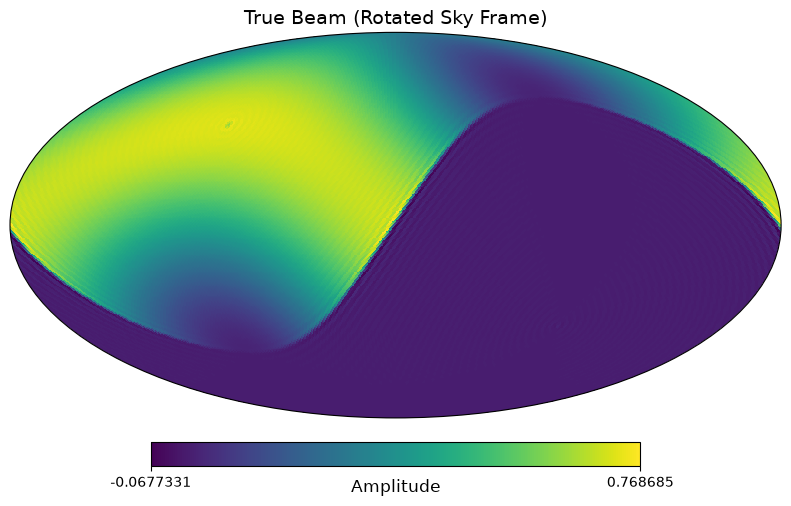

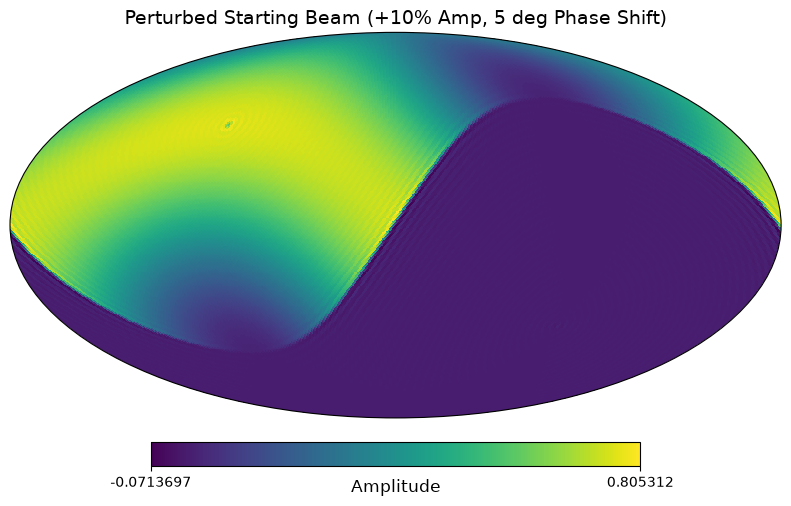

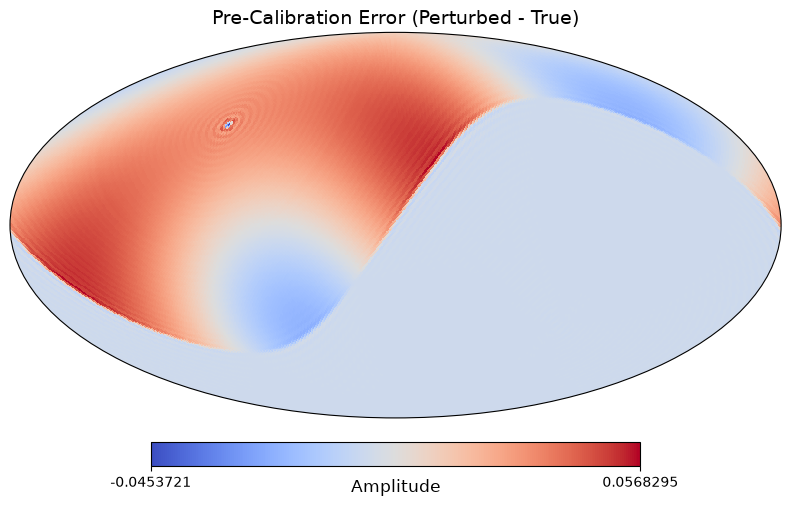

In [6]:
# 1. Choose which pointing and frequency to look at
b_idx = 0  # First pointing angle
f_idx = 0  # First frequency channel in your batch

# 2. Extract the maps IN THE ROTATED SKY FRAME via Inverse SHT
true_beam_pixel = s2fft.inverse_jax(
    beam_alms_TRUE_transformed[b_idx, f_idx],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real
true_map = np.asarray(true_beam_pixel)

pert_beam_pixel = s2fft.inverse_jax(
    beam_alms_PERTURBED_transformed[b_idx, f_idx],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real
pert_map = np.asarray(pert_beam_pixel)

# 3. Calculate the initial geometric error (Perturbed minus True)
diff_map = pert_map - true_map

print(
    f"--- Visualizing ROTATED Starting Beams (Pointing {b_idx}, Freq Index"
    f" {FREQ_START + f_idx}) ---"
)

# Plot the Rotated True Beam
hp.projview(
    true_map,
    title="True Beam (Rotated Sky Frame)",
    unit="Amplitude",
    cbar=True,
    cmap="viridis",
)
plt.show()

# Plot the Rotated Perturbed Starting Beam
hp.projview(
    pert_map,
    title="Perturbed Starting Beam (+10% Amp, 5 deg Phase Shift)",
    unit="Amplitude",
    cbar=True,
    cmap="viridis",
)
plt.show()

# Plot the Initial Residuals (The Starting Error Before Calibration)
hp.projview(
    diff_map,
    title="Pre-Calibration Error (Perturbed - True)",
    unit="Amplitude",
    cbar=True,
    cmap="coolwarm",  # Great for showing positive/negative deviations
)
plt.show()

In [7]:
twod_shape = (lmax + 1, 2 * lmax + 1)
oned_shape = 2 * Alm.getsize(lmax) - (lmax + 1)


def _build_alm_indices(lmax):
  rows, cols_pos, cols_neg, signs = [], [], [], []
  for m in range(1, lmax + 1):
    for l in range(m, lmax + 1):
      rows.append(l)
      cols_pos.append(lmax + m)
      cols_neg.append(lmax - m)
      signs.append((-1.0) ** m)
  return (
      jnp.array(rows),
      jnp.array(cols_pos),
      jnp.array(cols_neg),
      jnp.array(signs),
  )


_alm_rows, _alm_cols_pos, _alm_cols_neg, _alm_signs = _build_alm_indices(lmax)
_N_pos_m = len(_alm_rows)


def _unpack_single_freq(x_freq, lmax):
  m0_real = x_freq[: lmax + 1]
  pos_m_real = x_freq[lmax + 1 : lmax + 1 + _N_pos_m]
  pos_m_imag = x_freq[lmax + 1 + _N_pos_m :]
  pos_m_complex = (1 / jnp.sqrt(2)) * (pos_m_real + 1j * pos_m_imag)
  flm = jnp.zeros((lmax + 1, 2 * lmax + 1), dtype=jnp.complex128)
  flm = flm.at[:, lmax].set(m0_real + 0j, unique_indices=True)
  flm = flm.at[_alm_rows, _alm_cols_pos].set(
      pos_m_complex, unique_indices=True
  )
  flm = flm.at[_alm_rows, _alm_cols_neg].set(
      _alm_signs * jnp.conj(pos_m_complex), unique_indices=True
  )
  return flm


def _pack_single_freq(flm_freq, lmax):
  m0_real = jnp.real(flm_freq[:, lmax])
  pos_m_complex = jnp.sqrt(2) * flm_freq[_alm_rows, _alm_cols_pos]
  return jnp.concatenate(
      [m0_real, jnp.real(pos_m_complex), jnp.imag(pos_m_complex)]
  )


def s2fft_unravel(x_real, lmax):
  N_per_freq = (lmax + 1) ** 2
  x_reshaped = jnp.ravel(x_real).reshape(-1, N_per_freq)
  return jax.vmap(_unpack_single_freq, in_axes=(0, None))(x_reshaped, lmax)


def s2fft_ravel(flm_s2fft):
  L = flm_s2fft.shape[1]
  lmax = L - 1
  return jnp.ravel(
      jax.vmap(_pack_single_freq, in_axes=(0, None))(flm_s2fft, lmax)
  )

In [8]:
total_beam_num = beam_alms_TRUE_transformed.shape[0]


@jax.jit
def forward_true_universe(x_flat):
  """Generates mock data using the physically real, clean beams."""
  sky_alm_multi = s2fft_unravel(x_flat, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb",
      sky_alm_multi,
      phases.conjugate(),
      beam_alms_TRUE_transformed,
  )
  vis = vis.real / norms_TRUE.T[:, None, :]
  return vis.ravel()


# Generate your mock observed data from the true sky
x_true_flat = s2fft_ravel(true_sky_alm)
y_true = forward_true_universe(x_true_flat)


@jax.jit
def forward_perturbed_model(x_flat):
  """Used by the CG solver. Assumes the instrument has the 10% flaw."""
  sky_alm_multi = s2fft_unravel(x_flat, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb",
      sky_alm_multi,
      phases.conjugate(),
      beam_alms_PERTURBED_transformed,
  )
  vis = vis.real / norms_PERTURBED.T[:, None, :]
  return vis.ravel()


# Setup the Adjoint operations specifically for the perturbed starting guess model
_x0_multi = jnp.zeros(N_FREQS * oned_shape)
_adjoint_fn_perturbed = jax.linear_transpose(
    forward_perturbed_model, _x0_multi
)


@jax.jit
def adjoint_perturbed(y_flat):
  return _adjoint_fn_perturbed(y_flat)[0]


df = (freq[1] - freq[0]) if len(freq) > 1 else 1e6
times_jd = time_obs.jd + np.arange(ntimes) * dt_sim
dt = (times_jd[1] - times_jd[0]) * 24 * 3600

# Base thermal noise
noise_scale_factor = jnp.mean(jnp.abs(y_true))
thermal_sigma = noise_scale_factor / jnp.sqrt(df * dt)

# ADD A MODEL UNCERTAINTY FLOOR
# Since our beam has a 10% / 5-degree flaw, we must add a regularization
# floor (e.g., 15% of the visibility amplitude) to absorb the geometric mismatch.
model_uncertainty = 0.015 * jnp.abs(y_true)
effective_sigma = jnp.sqrt(thermal_sigma**2 + model_uncertainty**2)

Ndiag = effective_sigma**2

In [9]:
def almtohp(alm, lmax):
  alm_m0 = alm[: lmax + 1]
  N = len(alm) - len(alm_m0)
  alm_real = alm[lmax + 1 : lmax + 1 + N // 2]
  alm_imag = alm[lmax + 1 + N // 2 :]
  alm_c = 1 / jnp.sqrt(2) * (alm_real + 1j * alm_imag)
  hp_alm = jnp.concatenate((alm_m0, alm_c), dtype=complex)
  return hp_alm


# 1. Define the pixel integration area weight
omega_pix = 4.0 * jnp.pi / (12 * nside**2)

# --- S_diag Construction with Correct Variance Scaling ---
l_indices_m0 = jnp.arange(lmax + 1)
l_indices_mgt0 = jnp.concatenate(
    [jnp.arange(m, lmax + 1) for m in range(1, lmax + 1)]
)

all_s_diagonals = []
for i in range(N_FREQS):
  single_freq_sky = true_sky_alm[i : i + 1]
  ra_single = s2fft_ravel(single_freq_sky)
  true_hp = almtohp(ra_single, lmax)
  _cl_i = hp.alm2cl(np.asarray(true_hp))

  # Divide m > 0 components by 2.0 so total power Var(u) + Var(v) = C_l
  s_diag_i = jnp.concatenate([
      _cl_i[l_indices_m0],
      _cl_i[l_indices_mgt0] / 2.0,
      _cl_i[l_indices_mgt0] / 2.0,
  ])
  all_s_diagonals.append(s_diag_i)

S_diag2 = jnp.concatenate(all_s_diagonals)
peak_power = jnp.max(S_diag2)
S_diag2 = jnp.maximum(S_diag2, peak_power * 1e-4)

In [10]:
# 1. Dual-space operator for linear CG
@jax.jit
def matvec_M(x):
  return forward_perturbed_model(S_diag2 * adjoint_perturbed(x)) + Ndiag * x


print("1. Solving exact linear Wiener filter with CG...")
t0 = time.time()
alpha_cg, _ = jsp_linalg.cg(matvec_M, y_true, tol=1e-5, maxiter=200)
print(f"   ✓ CG solved in {time.time()-t0:.2f}s")

# 2. Reconstruct harmonic sky ALMs
x_wiener_raw = S_diag2 * adjoint_perturbed(alpha_cg)

# 3. Perform a single-pass positivity projection in pixel space
print("2. Projecting negative ringing to zero in map space...")
sky_alm_multi = s2fft_unravel(x_wiener_raw, lmax)
sky_alm_pos_list = []

for f in range(N_FREQS):
  # Transform to pixel map
  m = s2fft.inverse_jax(
      sky_alm_multi[f],
      L=lmax + 1,
      spin=0,
      nside=nside,
      sampling="healpix",
      reality=True,
  ).real

  # Clip negative sidelobes to zero
  m_pos = jnp.maximum(m, 0.0)

  # Transform back to ALM space
  alm_pos = s2fft.forward_jax(
      m_pos, L=lmax + 1, spin=0, nside=nside, sampling="healpix", reality=True
  )
  sky_alm_pos_list.append(alm_pos)

# Final positivity-constrained sky map
m_wiener = s2fft_ravel(jnp.stack(sky_alm_pos_list))

# 1. Compute predicted visibilities of the clipped map
y_pred_clipped = forward_perturbed_model(m_wiener)

# 2. Compute optimal scalar fit gamma
gamma = (
    jnp.vdot(y_true, y_pred_clipped).real
    / jnp.vdot(y_pred_clipped, y_pred_clipped).real
)

# 3. Apply optimal scaling factor
m_wiener = gamma * m_wiener

# 4. Verify visibility scale
test_vis = forward_perturbed_model(m_wiener)
print("\n--- AMPLITUDE CHECK ---")
print(f"Max |Predicted Vis| : {jnp.max(jnp.abs(test_vis)):.4e}")
print(f"Max |Target y_true|  : {jnp.max(jnp.abs(y_true)):.4e}")

1. Solving exact linear Wiener filter with CG...
   ✓ CG solved in 3.85s
2. Projecting negative ringing to zero in map space...

--- AMPLITUDE CHECK ---
Max |Predicted Vis| : 6.9726e+03
Max |Target y_true|  : 6.9774e+03


In [11]:
# 1. Define the plain Python function (no decorator!)
def truncate_high_l(x_flat, lmax_full, cutoff=10):
  """Zeroes out all spherical harmonic modes above a given cutoff.

  Assumes s2fft_unravel returns shape (..., L, M).
  """
  # Unravel the 1D flattened array back into the 2D (L, M) ALM grid
  sky_alm_2d = s2fft_unravel(x_flat, lmax_full)

  # Slice the L dimension and set everything above 'cutoff' to exactly 0 + 0j
  sky_alm_truncated = sky_alm_2d.at[..., cutoff + 1 :, :].set(0.0 + 0.0j)

  # Flatten it back into the 1D vector format
  return s2fft_ravel(sky_alm_truncated)


# 2. Manually JIT compile it, telling JAX that lmax_full (index 1) and cutoff (index 2) are static
truncate_high_l_jit = jax.jit(truncate_high_l, static_argnums=(1, 2))

# 3. Create the honest, low-pass filtered sky for Pass 1 using the JIT-compiled version
m_wiener_lowpass = truncate_high_l_jit(m_wiener, lmax, cutoff=2)

In [12]:
# 0. Define modes and slices from SVD outputs
N_MODES = 5
u_slice = jnp.array(u_svd[FREQ_START:FREQ_END, :N_MODES])  # (F, N_MODES)
v_slice = v_svd[:N_MODES]  # (N_MODES, NPIX)

# --- BUG FIX #2: incorporate the SVD singular values ---
# np.linalg.svd returns u_svd, s_svd, v_svd with u_svd/v_svd both unit-norm;
# without multiplying by s_svd, all N_MODES are treated as equally important
# regardless of their true weight in the beam decomposition. s_svd was
# computed where the SVD was run, but never referenced again anywhere in
# the original notebook.
s_slice = s_svd[:N_MODES]              # (N_MODES,)
v_slice = v_slice * s_slice[:, None]   # scale each spatial mode by its true SVD weight

# 1. Rotate the PCA modes for each pointing (Pure NumPy CPU)
rotated_modes_multi = []
for elaz in tqdm(elaz_pointings, desc="Rotating PCA modes"):
  rotated_modes_multi.append(rotate_bowtie(v_slice, elaz))

# Stack into a standard NumPy host array and zero out second half
modes_f = np.stack(rotated_modes_multi)  # Shape: (B, N_MODES, NPIX)
modes_f[..., npix // 2 :] = 0.0  # Fast, in-place NumPy zeroing

# 2. Convert PCA modes to ALMs (Pure CPU using ducc0 C-contiguous slices)
mode_alms_list = []
for b_idx in tqdm(range(modes_f.shape[0]), desc="SHT on PCA modes"):
  m_alms_k = []
  for k in range(N_MODES):
    # np.ascontiguousarray ensures C++ receives clean host memory pointers
    slice_cpu = np.ascontiguousarray(modes_f[b_idx, k])
    m_alm = s2fft.forward(
        slice_cpu,
        L=lmax + 1,
        spin=0,
        nside=nside,
        sampling="healpix",
        reality=True,
    )
    m_alms_k.append(m_alm)
  mode_alms_list.append(np.stack(m_alms_k))

mode_alms = np.stack(mode_alms_list)  # Shape: (B, N_MODES, L, M) on CPU

# 3. Rotate to FK5 fully vectorized on GPU (Zero Python loops!)
print("Vectorizing topo2fk5 across all pointings and modes...")

# Transfer CPU mode ALMs to GPU JAX array
mode_alms_jax = jnp.array(mode_alms)  # Shape: (B, N_MODES, L, M)

# Double-vmap: inner vmap handles N_MODES, outer vmap handles Pointings (B)
topo2fk5_vectorized = jax.jit(jax.vmap(jax.vmap(topo2fk5)))

# Execute all 100 rotations simultaneously in GPU memory
mode_alms_fk5 = topo2fk5_vectorized(mode_alms_jax)  # Shape: (B, N_MODES, L, M)

# 4. Construct the MCMC Mode Tensor
mode_tensor = jnp.einsum("fk, bklm -> kbflm", u_slice, mode_alms_fk5)

print(f"PCA Mode Tensor ready for MCMC! Shape: {mode_tensor.shape}")

Rotating PCA modes:   0%|          | 0/20 [00:00<?, ?it/s]

SHT on PCA modes:   0%|          | 0/20 [00:00<?, ?it/s]

Vectorizing topo2fk5 across all pointings and modes...
PCA Mode Tensor ready for MCMC! Shape: (5, 20, 8, 129, 257)


In [13]:
# --- DIAGNOSTIC: DOES THE 5-MODE PCA BASIS EVEN SPAN THE INJECTED ERROR? ---
true_error_alm = beam_alms_TRUE_transformed - beam_alms_PERTURBED_transformed
n_modes = mode_tensor.shape[0]
mode_mat = mode_tensor.reshape(n_modes, -1)      # (K, B*F*L*M) complex
error_vec = true_error_alm.reshape(-1)           # (B*F*L*M,) complex

mode_mat_ri = jnp.concatenate([mode_mat.real, mode_mat.imag], axis=1)   # (K, 2N)
error_vec_ri = jnp.concatenate([error_vec.real, error_vec.imag])       # (2N,)

p_best_fit, *_ = jnp.linalg.lstsq(mode_mat_ri.T, error_vec_ri, rcond=None)
reconstructed_ri = mode_mat_ri.T @ p_best_fit

captured_power = jnp.sum(reconstructed_ri**2)
total_power = jnp.sum(error_vec_ri**2)
overlap_frac = captured_power / total_power

print(f"Injected beam-error power captured by the {n_modes}-mode basis: {100*overlap_frac:.2f}%")
print(f"Oracle best-fit p in this basis (what a perfect solver would find): {p_best_fit}")

# cheat_sky_flat is used throughout the rest of this notebook (cheat tests
# using the TRUE sky, to isolate basis/normalization/degeneracy questions
# from the separate sky-estimation question). Defined here since
# true_sky_alm is available from the setup cells above.
cheat_sky_flat = s2fft_ravel(true_sky_alm)


Injected beam-error power captured by the 5-mode basis: 69.19%
Oracle best-fit p in this basis (what a perfect solver would find): [-0.04690933 -0.04697802 -0.04652335 -0.04626697 -0.03768661]


In [14]:
# --- SHARED UTILITY: recompute per-(pointing,freq) beam power from the ---
# --- CURRENT beam (fix #3), rather than a stale fixed-beam snapshot. ---
# Pulled out to its own cell (previously defined inside the alternating-loop
# cell) so it is available to the diagnostic cells below too, which test the
# ORIGINAL (pre-calibration) Wiener behavior and need this before the main
# calibration loop runs.
def compute_norms_curr(beam_curr):
  return jax.vmap(jax.vmap(lambda a: crojax.alm.total_power(a, lmax)))(
      beam_curr
  )  # (B, F), same convention as norms_TRUE / norms_PERTURBED


In [15]:
# --- SANITY CHECK: HOW BIG IS THE ACTUAL INJECTED PERTURBATION, REALLY? ---
# create_perturbed_base_map applies a UNIFORM complex scalar
# (amp_scale * exp(i*phase)) to every alm coefficient, THEN a power-
# conservation rescale (u_scale = sqrt(true_power/perturbed_power_raw)) is
# applied. Since total_power scales as |scalar|^2 under a uniform complex
# multiply, and amp_scale is real and positive, this rescale divides out
# almost exactly amp_scale's contribution to total power algebraically -
# worth confirming directly rather than assuming, since s2fft's real-SHT
# storage convention (m>=0 only, symmetry reconstructed on synthesis) can
# make naive complex-multiply algebra behave unexpectedly.

true_power_check = crojax.alm.total_power(beam_alms_TRUE_transformed[0], lmax)
pert_power_check = crojax.alm.total_power(beam_alms_PERTURBED_transformed[0], lmax)
print(f"total_power(TRUE beam, pointing 0)      : {true_power_check}")
print(f"total_power(PERTURBED beam, pointing 0) : {pert_power_check}")
print(f"power ratio (perturbed/true)             : {pert_power_check/true_power_check}")

err_now = beam_alms_TRUE_transformed - beam_alms_PERTURBED_transformed
rel_err = jnp.linalg.norm(err_now.reshape(-1)) / jnp.linalg.norm(beam_alms_TRUE_transformed.reshape(-1))
print(f"\nRelative alm-space error |TRUE-PERTURBED|/|TRUE| : {100*rel_err:.4f}%")
print(
    "If the power ratio above is very close to 1.0 despite amp_scale=1.10 "
    "being requested, the power-conservation rescale in cell 3 is "
    "canceling out the amplitude component of the perturbation, leaving "
    "close to a pure phase-only error - worth knowing before interpreting "
    "the alpha-sweep diagnostic below."
)


total_power(TRUE beam, pointing 0)      : [2.98600308 3.07058354 3.1547168  3.23832433 3.32132939 3.4036568
 3.48523358 3.56598855]
total_power(PERTURBED beam, pointing 0) : [3.12577472 3.21431423 3.30238561 3.38990665 3.47679706 3.56297805
 3.64837328 3.7329082 ]
power ratio (perturbed/true)             : [1.04680894 1.04680892 1.0468089  1.04680888 1.04680887 1.04680885
 1.04680883 1.0468088 ]

Relative alm-space error |TRUE-PERTURBED|/|TRUE| : 5.6263%
If the power ratio above is very close to 1.0 despite amp_scale=1.10 being requested, the power-conservation rescale in cell 3 is canceling out the amplitude component of the perturbation, leaving close to a pure phase-only error - worth knowing before interpreting the alpha-sweep diagnostic below.


Solving with a SINGLE pointing (index 0)...
Solving with ALL 20 pointings...

Single-pointing reconstruction: peak = 13442.71, min = 1368.53
All-20-pointing reconstruction:  peak = 14836.25, min = 264.72
If the single-pointing peak is notably sharper/higher and the 20-pointing peak is smeared out and lower (or goes negative elsewhere), that is consistent with inter-pointing disagreement smearing the reconstruction - though note ALL 20 pointings currently carry the exact SAME fractional beam error (a uniform complex-scalar perturbation applied before rotation), so any smearing here would have to come from how that identical error interacts differently with each pointing's distinct sky view, not from the pointings disagreeing with each other about the error itself.


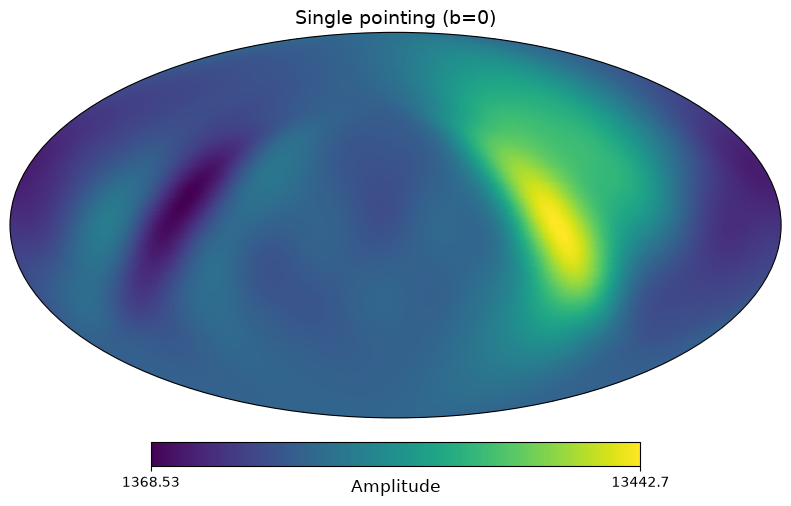

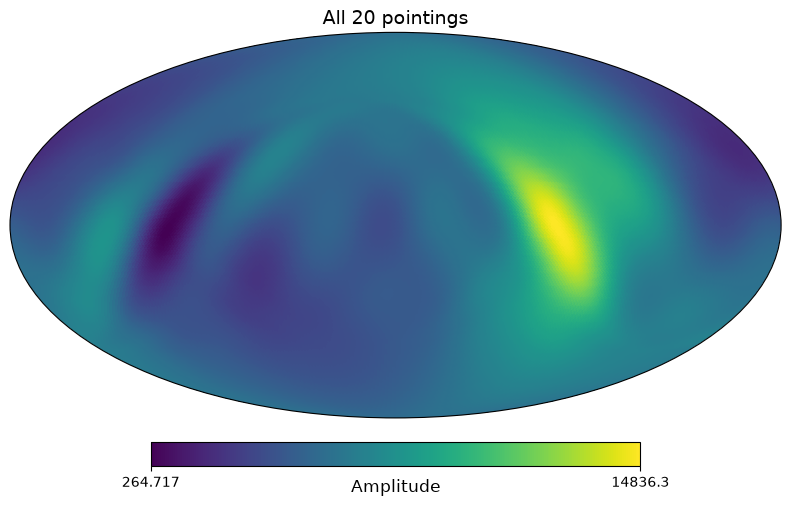

In [16]:
# --- DIAGNOSTIC 1: SINGLE POINTING vs. ALL 20, ORIGINAL (UNCALIBRATED) BEAM ---
# Tests whether combining all 20 pointings (each carrying the SAME
# uncorrected beam error) smears out sharp structure that a single
# pointing alone would recover cleanly - using the plain Wiener filter,
# no beam calibration (p=0), matching the very first Wiener pass this
# notebook ever ran.

def solve_wiener_generic(beam_arr, pointing_indices):
  """Wiener-filter solve for the sky using only `pointing_indices` of the
  pointings, with the given per-pointing beam alm array `beam_arr`
  (shape (len(pointing_indices), F, L, M))."""
  y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
  Ndiag_3d = Ndiag.reshape(N_FREQS, ntimes, total_beam_num)
  y_sub = y_true_3d[:, :, pointing_indices].reshape(-1)
  Ndiag_sub = Ndiag_3d[:, :, pointing_indices].reshape(-1)
  norms_sub = compute_norms_curr(beam_arr)

  def forward_sub(x_flat):
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum(
        "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_arr
    )
    return (vis.real / norms_sub.T[:, None, :]).ravel()

  _adj_sub = jax.linear_transpose(forward_sub, _x0_multi)

  def matvec_sub(a):
    x_sky = S_diag2 * _adj_sub(a)[0]
    return forward_sub(x_sky) + Ndiag_sub * a

  alpha_sol, _ = jsp_linalg.cg(matvec_sub, y_sub, tol=1e-4, maxiter=100)
  return S_diag2 * _adj_sub(alpha_sol)[0]


B_total = beam_alms_PERTURBED_transformed.shape[0]

print("Solving with a SINGLE pointing (index 0)...")
x_sky_single = solve_wiener_generic(
    beam_alms_PERTURBED_transformed[0:1], [0]
)

print("Solving with ALL " + str(B_total) + " pointings...")
x_sky_all = solve_wiener_generic(
    beam_alms_PERTURBED_transformed, list(range(B_total))
)

def _peak_map(x_flat, f_idx=0):
  sky_alm_multi = s2fft_unravel(x_flat, lmax)
  m = s2fft.inverse_jax(
      sky_alm_multi[f_idx], L=lmax + 1, spin=0, nside=nside,
      sampling="healpix", reality=True,
  ).real
  return np.asarray(m)

map_single = _peak_map(x_sky_single)
map_all = _peak_map(x_sky_all)

print(f"\nSingle-pointing reconstruction: peak = {map_single.max():.2f}, min = {map_single.min():.2f}")
print(f"All-{B_total}-pointing reconstruction:  peak = {map_all.max():.2f}, min = {map_all.min():.2f}")
print(
    "If the single-pointing peak is notably sharper/higher and the "
    "20-pointing peak is smeared out and lower (or goes negative "
    "elsewhere), that is consistent with inter-pointing disagreement "
    "smearing the reconstruction - though note ALL 20 pointings currently "
    "carry the exact SAME fractional beam error (a uniform complex-scalar "
    "perturbation applied before rotation), so any smearing here would "
    "have to come from how that identical error interacts differently "
    "with each pointing's distinct sky view, not from the pointings "
    "disagreeing with each other about the error itself."
)

# --- FIX: healpix maps are flat 1D arrays (49152,), not 2D images - use ---
# --- hp.projview (as the rest of this notebook does), not plt.imshow ---
hp.projview(
    map_single,
    title="Single pointing (b=0)",
    unit="Amplitude",
    cbar=True,
    cmap="viridis",
)
plt.show()

hp.projview(
    map_all,
    title=f"All {B_total} pointings",
    unit="Amplitude",
    cbar=True,
    cmap="viridis",
)
plt.show()


alpha=1.0    : peak =    4742.74   min =   -9685.58
alpha=0.1    : peak =   14572.42   min =     430.83
alpha=0.01   : peak =   10552.18   min =   -3522.32
alpha=0.001  : peak =   14480.30   min =     488.66
alpha=0.0    : peak =   14528.87   min =     487.58


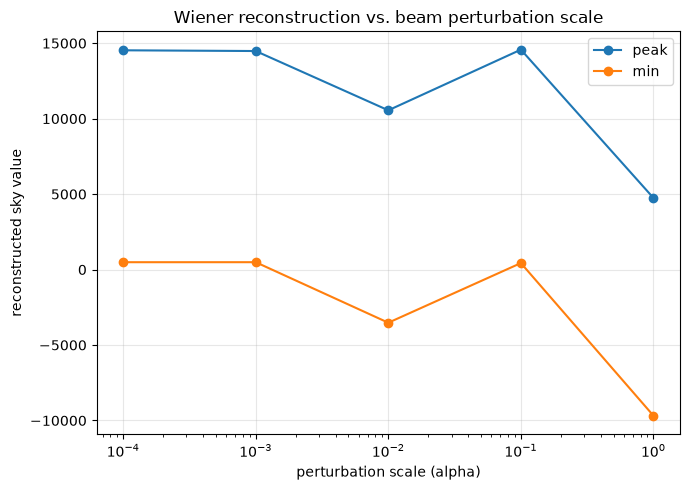


Look for a SHARP transition (a narrow alpha range where peak drops or min goes sharply negative) vs. SMOOTH, gradual degradation. A sharp threshold would suggest a specific breakdown point (e.g. the unbounded-objective/degeneracy issues found earlier in this session); smooth degradation is more consistent with ordinary, expected model-mismatch sensitivity.


In [17]:
# --- DIAGNOSTIC 2: SWEEP THE PERTURBATION SCALE ---
# Interpolates linearly in alm-space between the TRUE beam (alpha=0) and
# the actual injected PERTURBED beam (alpha=1), rather than re-deriving
# amp_scale/phase_shift_deg values directly - sidesteps the reality=True /
# hermitian-symmetry subtlety flagged in the sanity-check cell above, and
# more directly answers "how does reconstruction quality degrade as beam
# error grows", using ALL pointings and the same solve_wiener_generic
# helper from diagnostic 1 above.

alphas = [1.0, 0.1, 0.01, 0.001, 0.0]
peak_values = []
min_values = []

for alpha in alphas:
  beam_scaled = beam_alms_TRUE_transformed + alpha * (
      beam_alms_PERTURBED_transformed - beam_alms_TRUE_transformed
  )
  x_sky_scaled = solve_wiener_generic(beam_scaled, list(range(B_total)))
  m_scaled = _peak_map(x_sky_scaled)
  peak_values.append(float(m_scaled.max()))
  min_values.append(float(m_scaled.min()))
  print(f"alpha={alpha:<7}: peak = {peak_values[-1]:10.2f}   min = {min_values[-1]:10.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
plot_alphas = [a if a > 0 else 1e-4 for a in alphas]  # avoid log(0)
ax.plot(plot_alphas, peak_values, "o-", label="peak")
ax.plot(plot_alphas, min_values, "o-", label="min")
ax.set_xscale("log")
ax.set_xlabel("perturbation scale (alpha)")
ax.set_ylabel("reconstructed sky value")
ax.set_title("Wiener reconstruction vs. beam perturbation scale")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "\nLook for a SHARP transition (a narrow alpha range where peak drops "
    "or min goes sharply negative) vs. SMOOTH, gradual degradation. A "
    "sharp threshold would suggest a specific breakdown point (e.g. the "
    "unbounded-objective/degeneracy issues found earlier in this session); "
    "smooth degradation is more consistent with ordinary, expected "
    "model-mismatch sensitivity."
)



current settings (tol=1e-4, maxiter=100):
  CG info (0 = converged): None
  peak=14528.87  min=487.58  RMSE vs true=3194.49  rel_err=43.59%


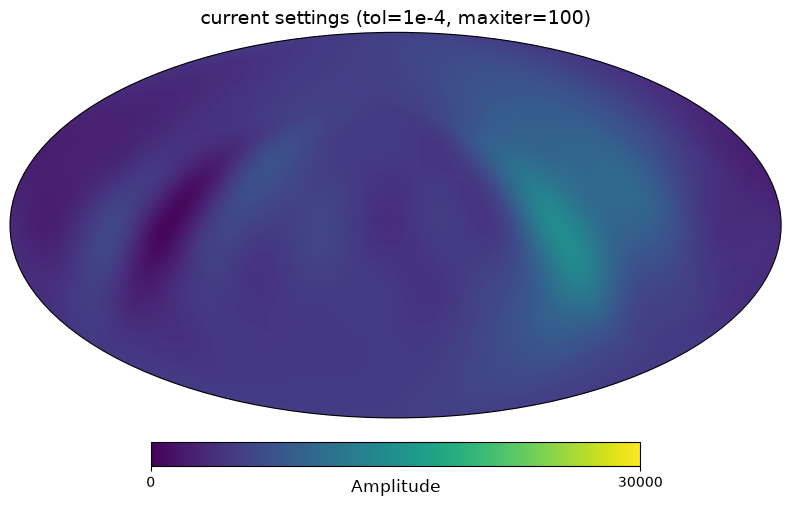


old-notebook settings (tol=1e-6, maxiter=1000):
  CG info (0 = converged): None
  peak=18025.22  min=1150.45  RMSE vs true=2634.95  rel_err=35.95%


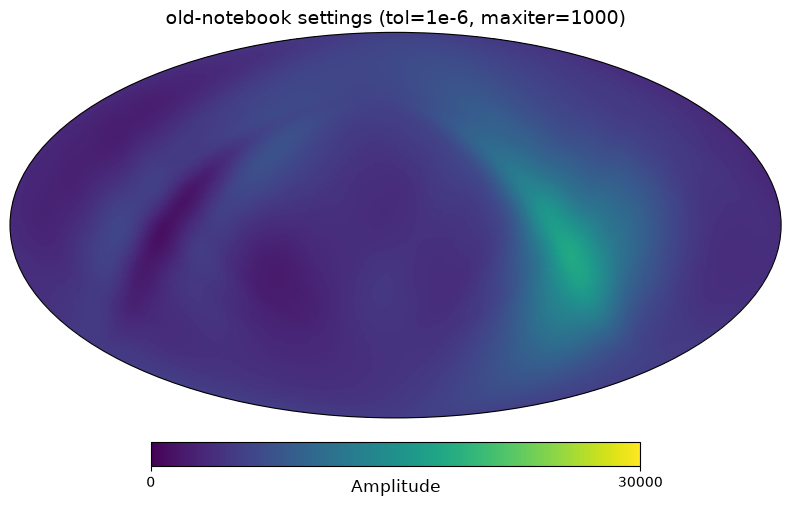

In [18]:
# --- IS UNDER-CONVERGED CG THE REAL EXPLANATION, NOT BEAM ERROR? ---
# Old notebook: tol=1e-6, maxiter=1000. Current pipeline: tol=1e-4,
# maxiter=100 - two orders of magnitude looser, 10x fewer iterations.
# Test with the PERFECT beam (alpha=0, zero beam error) so any quality
# difference here can ONLY come from convergence settings, not beam error.

def solve_wiener_tight(beam_arr, pointing_indices, tol, maxiter):
  y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
  Ndiag_3d = Ndiag.reshape(N_FREQS, ntimes, total_beam_num)
  y_sub = y_true_3d[:, :, pointing_indices].reshape(-1)
  Ndiag_sub = Ndiag_3d[:, :, pointing_indices].reshape(-1)
  norms_sub = compute_norms_curr(beam_arr)

  def forward_sub(x_flat):
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum(
        "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_arr
    )
    return (vis.real / norms_sub.T[:, None, :]).ravel()

  _adj_sub = jax.linear_transpose(forward_sub, _x0_multi)

  def matvec_sub(a):
    x_sky = S_diag2 * _adj_sub(a)[0]
    return forward_sub(x_sky) + Ndiag_sub * a

  alpha_sol, info = jsp_linalg.cg(matvec_sub, y_sub, tol=tol, maxiter=maxiter)
  print(f"  CG info (0 = converged): {info}")
  return S_diag2 * _adj_sub(alpha_sol)[0]


true_sky_pixel = s2fft.inverse_jax(
    true_sky_alm[0], L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real
true_sky_map = np.asarray(true_sky_pixel)
true_sky_rms = np.sqrt(np.mean(true_sky_map**2))

for label, tol, maxiter in [
    ("current settings (tol=1e-4, maxiter=100)", 1e-4, 100),
    ("old-notebook settings (tol=1e-6, maxiter=1000)", 1e-6, 1000),
]:
  print(f"\n{label}:")
  x_sky_perfect = solve_wiener_tight(
      beam_alms_TRUE_transformed, list(range(B_total)), tol, maxiter
  )
  m_perfect = _peak_map(x_sky_perfect)
  rmse = np.sqrt(np.mean((m_perfect - true_sky_map) ** 2))
  print(f"  peak={m_perfect.max():.2f}  min={m_perfect.min():.2f}  "
        f"RMSE vs true={rmse:.2f}  rel_err={100*rmse/true_sky_rms:.2f}%")
  hp.projview(m_perfect, title=label, unit="Amplitude", cbar=True,
              cmap="viridis", min=0, max=3e4)
  plt.show()

thermal_sigma (scalar): 0.0013
model_uncertainty range: 47.7888 to 104.6609
mean(Ndiag) [current, with floor]: 5448.4744
mean(Ndiag_thermal_only)          : 0.0000
ratio (current/thermal-only)      : 3470437773.38x

thermal-only Ndiag: peak=21568.23  min=142.02  RMSE vs true=2445.07  rel_err=33.36%


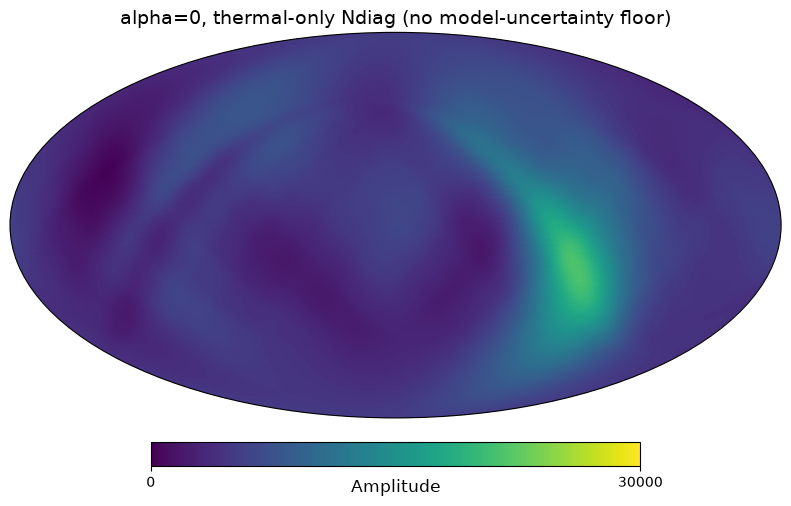

In [19]:
# --- IS THE 1.5% "MODEL UNCERTAINTY FLOOR" THE REAL CULPRIT? ---
# Same alpha=0 (perfect beam) test as before, but with Ndiag built from
# ONLY the genuine thermal term, dropping the model_uncertainty floor that
# was added specifically to absorb BEAM mismatch - which shouldn't be
# needed at all when the beam is exactly correct.

Ndiag_thermal_only = thermal_sigma**2 * jnp.ones_like(Ndiag)
print(f"thermal_sigma (scalar): {float(thermal_sigma):.4f}")
print(f"model_uncertainty range: {float(jnp.min(model_uncertainty)):.4f} to {float(jnp.max(model_uncertainty)):.4f}")
print(f"mean(Ndiag) [current, with floor]: {float(jnp.mean(Ndiag)):.4f}")
print(f"mean(Ndiag_thermal_only)          : {float(jnp.mean(Ndiag_thermal_only)):.4f}")
print(f"ratio (current/thermal-only)      : {float(jnp.mean(Ndiag)/jnp.mean(Ndiag_thermal_only)):.2f}x")

def solve_wiener_custom_noise(beam_arr, pointing_indices, ndiag_full, tol, maxiter):
  y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
  ndiag_3d = ndiag_full.reshape(N_FREQS, ntimes, total_beam_num)
  y_sub = y_true_3d[:, :, pointing_indices].reshape(-1)
  ndiag_sub = ndiag_3d[:, :, pointing_indices].reshape(-1)
  norms_sub = compute_norms_curr(beam_arr)

  def forward_sub(x_flat):
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum(
        "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_arr
    )
    return (vis.real / norms_sub.T[:, None, :]).ravel()

  _adj_sub = jax.linear_transpose(forward_sub, _x0_multi)

  def matvec_sub(a):
    x_sky = S_diag2 * _adj_sub(a)[0]
    return forward_sub(x_sky) + ndiag_sub * a

  alpha_sol, info = jsp_linalg.cg(matvec_sub, y_sub, tol=tol, maxiter=maxiter)
  return S_diag2 * _adj_sub(alpha_sol)[0]


x_sky_thermal = solve_wiener_custom_noise(
    beam_alms_TRUE_transformed, list(range(B_total)), Ndiag_thermal_only, 1e-6, 1000
)
m_thermal = _peak_map(x_sky_thermal)
rmse_thermal = np.sqrt(np.mean((m_thermal - true_sky_map) ** 2))
print(f"\nthermal-only Ndiag: peak={m_thermal.max():.2f}  min={m_thermal.min():.2f}  "
      f"RMSE vs true={rmse_thermal:.2f}  rel_err={100*rmse_thermal/true_sky_rms:.2f}%")

hp.projview(m_thermal, title="alpha=0, thermal-only Ndiag (no model-uncertainty floor)",
            unit="Amplitude", cbar=True, cmap="viridis", min=0, max=3e4)
plt.show()

In [20]:
print(f"df = {float(df):.6e}")
print(f"dt = {float(dt):.6e}")
print(f"df * dt = {float(df*dt):.6e}")
print(f"noise_scale_factor (mean|y_true|) = {float(noise_scale_factor):.6e}")
print(f"thermal_sigma (full precision) = {float(thermal_sigma):.6e}")
print(f"\nvivaldi freqs used: {freq}")

df = 1.000000e+06
dt = 1.488917e+07
df * dt = 1.488917e+13
noise_scale_factor (mean|y_true|) = 4.834824e+03
thermal_sigma (full precision) = 1.252983e-03

vivaldi freqs used: [52000000. 53000000. 54000000. 55000000. 56000000. 57000000. 58000000.
 59000000.]


In [21]:
# --- FIXED df, then a GRADED sweep of the model-uncertainty floor ---
df_fixed = (freq[1] - freq[0]) if len(freq) > 1 else 1e6
thermal_sigma_fixed = noise_scale_factor / jnp.sqrt(df_fixed * dt)
print(f"df_fixed = {float(df_fixed):.4e}, thermal_sigma_fixed = {float(thermal_sigma_fixed):.4e}")

true_sky_pixel = s2fft.inverse_jax(
    true_sky_alm[0], L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real
true_sky_map = np.asarray(true_sky_pixel)
true_sky_rms = np.sqrt(np.mean(true_sky_map**2))

def solve_wiener_custom_noise(beam_arr, pointing_indices, ndiag_full, tol, maxiter):
  y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
  ndiag_3d = ndiag_full.reshape(N_FREQS, ntimes, total_beam_num)
  y_sub = y_true_3d[:, :, pointing_indices].reshape(-1)
  ndiag_sub = ndiag_3d[:, :, pointing_indices].reshape(-1)
  norms_sub = compute_norms_curr(beam_arr)

  def forward_sub(x_flat):
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum(
        "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_arr
    )
    return (vis.real / norms_sub.T[:, None, :]).ravel()

  _adj_sub = jax.linear_transpose(forward_sub, _x0_multi)

  def matvec_sub(a):
    x_sky = S_diag2 * _adj_sub(a)[0]
    return forward_sub(x_sky) + ndiag_sub * a

  alpha_sol, info = jsp_linalg.cg(matvec_sub, y_sub, tol=tol, maxiter=maxiter)
  return S_diag2 * _adj_sub(alpha_sol)[0]


for floor_coeff in [0.015, 0.005, 0.0015, 0.00015]:
  model_unc = floor_coeff * jnp.abs(y_true)
  ndiag_test = thermal_sigma_fixed**2 + model_unc**2
  x_sky_test = solve_wiener_custom_noise(
      beam_alms_TRUE_transformed, list(range(B_total)), ndiag_test, 1e-6, 1000
  )
  m_test = _peak_map(x_sky_test)
  rmse = np.sqrt(np.mean((m_test - true_sky_map) ** 2))
  print(f"floor_coeff={floor_coeff:<8}: peak={m_test.max():9.2f}  "
        f"min={m_test.min():9.2f}  rel_err={100*rmse/true_sky_rms:6.2f}%")

df_fixed = 1.0000e+06, thermal_sigma_fixed = 1.2530e-03
floor_coeff=0.015   : peak= 18025.16  min=  1150.52  rel_err= 35.95%
floor_coeff=0.005   : peak= 20678.24  min=  1640.83  rel_err= 33.18%
floor_coeff=0.0015  : peak= 21677.88  min=  1172.45  rel_err= 32.96%
floor_coeff=0.00015 : peak= 21711.89  min=   716.26  rel_err= 33.02%


Single-frequency-only solve: peak=21834.91  min=1602.44  rel_err=31.95%


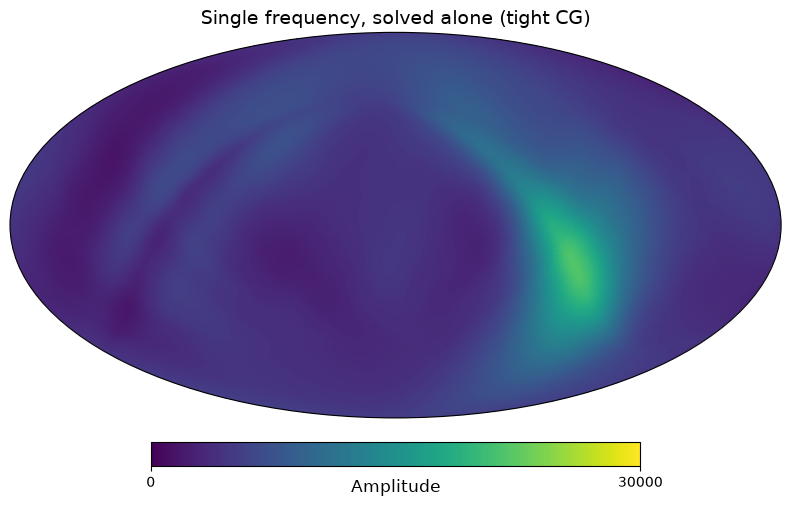

In [22]:
# --- IS THE MULTI-FREQUENCY JOINT SOLVE UNDER-CONVERGING PER FREQUENCY? ---
# No cross-frequency coupling exists anywhere in this model (the einsum
# never sums over f) - so a single-frequency slice, solved alone, should
# be mathematically equivalent to that frequency's own block within the
# joint 8-frequency solve, MINUS any effect of sharing a CG iteration
# budget across all 8 blocks at once.

f0 = 0  # first frequency in the current FREQ_START:FREQ_END range

y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
Ndiag_3d = Ndiag.reshape(N_FREQS, ntimes, total_beam_num)
y_single = y_true_3d[f0:f0+1].reshape(-1)
Ndiag_single = (thermal_sigma_fixed**2 + (0.0015 * jnp.abs(y_true_3d[f0:f0+1]))**2).reshape(-1)

S_diag2_2d = S_diag2.reshape(N_FREQS, -1)
S_diag2_single = S_diag2_2d[f0]

beam_true_single = beam_alms_TRUE_transformed[:, f0:f0+1, :, :]
_x0_single = jnp.zeros(oned_shape)

def forward_single(x_flat):
  sky_alm_single = s2fft_unravel(x_flat, lmax)  # N_FREQS=1 internally here
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_single, phases.conjugate(), beam_true_single
  )
  norms_single = compute_norms_curr(beam_true_single)
  return (vis.real / norms_single.T[:, None, :]).ravel()

_adj_single = jax.linear_transpose(forward_single, _x0_single)

def matvec_single(a):
  x_sky = S_diag2_single * _adj_single(a)[0]
  return forward_single(x_sky) + Ndiag_single * a

alpha_sol_single, info = jsp_linalg.cg(matvec_single, y_single, tol=1e-6, maxiter=1000)
x_sky_single_solve = S_diag2_single * _adj_single(alpha_sol_single)[0]

sky_alm_check = s2fft_unravel(x_sky_single_solve, lmax)
m_single = np.asarray(s2fft.inverse_jax(
    sky_alm_check[0], L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real)

true_sky_pixel_f0 = s2fft.inverse_jax(
    true_sky_alm[f0], L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real
true_sky_map_f0 = np.asarray(true_sky_pixel_f0)
true_sky_rms_f0 = np.sqrt(np.mean(true_sky_map_f0**2))

rmse_single = np.sqrt(np.mean((m_single - true_sky_map_f0) ** 2))
print(f"Single-frequency-only solve: peak={m_single.max():.2f}  min={m_single.min():.2f}  "
      f"rel_err={100*rmse_single/true_sky_rms_f0:.2f}%")

hp.projview(m_single, title="Single frequency, solved alone (tight CG)",
            unit="Amplitude", cbar=True, cmap="viridis", min=0, max=3e4)
plt.show()

In [ ]:
# --- ITERATIVE JOINT SELF-CALIBRATION (ALTERNATING BLOCK DESCENT) ---
# Fixes applied: #2 (mode_tensor, above), #3 (normalization, via
# compute_norms_curr defined in the utility cell above), #6 (LBFGS
# compiled once instead of every call). Fix #4 (ICM/sky-absorption) is
# addressed by the damped-loop comparison cell below, not folded in here.


# --- Fix #6: build the beam-fitting loss + LBFGS solver ONCE, at module
# scope. x_constrained and prior_sigma are explicit runtime arguments, not
# closure captures, so this compiles a single time and every later call -
# from any loop, any cell - reuses the same cached executable instead of
# triggering a fresh compile (which is what was almost certainly driving
# the repeated kernel crashes across this whole session).
def _beam_loss_core(p, x_constrained, prior_sigma):
  perturbation = jnp.einsum("k, kbf... -> bf...", p, mode_tensor)
  beam_curr = beam_alms_PERTURBED_transformed + perturbation
  norms_curr = compute_norms_curr(beam_curr)
  sky_alm_multi = s2fft_unravel(x_constrained, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_curr
  )
  y_pred = (vis.real / norms_curr.T[:, None, :]).ravel()
  res = (y_true - y_pred) / jnp.sqrt(Ndiag)
  chi2 = 0.5 * jnp.sum(res**2)
  prior = 0.5 * jnp.sum((p / prior_sigma) ** 2)
  return chi2 + prior


_lbfgs_beam = jaxopt.LBFGS(fun=_beam_loss_core, maxiter=20, tol=1e-3)


def optimize_beam_step(x_constrained, p_init, prior_sigma=0.1):
  """Step 2: Optimize beam parameters p against the constrained sky map.
  sigma=0.1 is correctly scaled now that mode_tensor includes the s_svd
  weighting - the oracle lstsq fit needs |p| ~ 0.04-0.05."""
  res = _lbfgs_beam.run(p_init, x_constrained, prior_sigma)
  return res.params


def solve_sky_step(p_current):
  """Step 1: Solve Wiener Filter sky for current beam p, then enforce positivity."""
  perturbation = jnp.einsum("k, kbf... -> bf...", p_current, mode_tensor)
  beam_curr = beam_alms_PERTURBED_transformed + perturbation
  norms_curr = compute_norms_curr(beam_curr)

  def forward_curr(x_flat):
    sky_alm_multi = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum(
        "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_curr
    )
    return (vis.real / norms_curr.T[:, None, :]).ravel()

  _adj_curr = jax.linear_transpose(forward_curr, _x0_multi)

  def matvec_curr(alpha):
    x_sky = S_diag2 * _adj_curr(alpha)[0]
    return forward_curr(x_sky) + Ndiag * alpha

  alpha_cg, _ = jsp_linalg.cg(matvec_curr, y_true, tol=1e-4, maxiter=100)
  x_raw = S_diag2 * _adj_curr(alpha_cg)[0]

  sky_alm_multi = s2fft_unravel(x_raw, lmax)
  sky_alm_pos_list = []
  for f in range(N_FREQS):
    m = s2fft.inverse_jax(
        sky_alm_multi[f], L=lmax + 1, spin=0, nside=nside,
        sampling="healpix", reality=True,
    ).real
    m_pos = jnp.maximum(m, 0.0)
    alm_pos = s2fft.forward_jax(
        m_pos, L=lmax + 1, spin=0, nside=nside, sampling="healpix", reality=True
    )
    sky_alm_pos_list.append(alm_pos)

  m_pos_flat = s2fft_ravel(jnp.stack(sky_alm_pos_list))

  y_pred = forward_curr(m_pos_flat)
  gamma = jnp.vdot(y_true, y_pred).real / jnp.vdot(y_pred, y_pred).real
  return gamma * m_pos_flat, x_raw


# --- RUN ITERATIVE SELF-CALIBRATION ---
# FIX #9: track the best-seen (lowest-loss) p across ALL iterations, not
# just whatever the final one happens to be. Both this loop and the damped
# loop have shown a pattern of finding a good, oracle-like answer partway
# through, then jumping to a much larger, spurious point in a later round
# (the same unbounded-objective issue characterized in chat). Using the
# best-seen point makes a run robust to that pattern - and to a mid-run
# crash - without needing every iteration to behave.
p_joint = jnp.zeros(N_MODES)
best_p_joint = p_joint
best_loss_joint = float(_beam_loss_core(p_joint, _x0_multi, 0.1))
print("Starting Iterative Joint Self-Calibration Loop...")

for iter_i in range(5):
  t0 = time.time()

  # Step 1: Re-solve Sky given current Beam
  x_sky_pos, x_raw_final = solve_sky_step(p_joint)

  # Step 2: Optimize Beam given clipped Sky
  p_joint = optimize_beam_step(x_sky_pos, p_joint)

  loss_now = float(_beam_loss_core(p_joint, x_sky_pos, 0.1))
  is_best = loss_now < best_loss_joint
  if is_best:
    best_loss_joint = loss_now
    best_p_joint = p_joint

  tag = "  <- best so far" if is_best else ""
  print("Iteration " + str(iter_i + 1) + "/5 completed in "
        + str(round(time.time() - t0, 2)) + "s | p: " + str(p_joint)
        + " | loss=" + str(round(loss_now, 4)) + tag)

mean_p = best_p_joint  # use the BEST-SEEN point, not necessarily the last one
print("")
print("   \u2713 Joint Self-Calibration Converged!")
print("Best-loss beam parameters (loss=" + str(round(best_loss_joint, 4)) + "): " + str(mean_p))
print("(Final iteration's p, for reference: " + str(p_joint) + ")")

# --- RECONSTRUCT FINAL CALIBRATED BEAM AND SKY MAP ---
best_perturbation = jnp.einsum("k, kbf... -> bf...", mean_p, mode_tensor)
best_beam = beam_alms_PERTURBED_transformed + best_perturbation
_norms_best_beam = compute_norms_curr(best_beam)


def forward_calibrated_model(x_flat):
  sky_alm_multi = s2fft_unravel(x_flat, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), best_beam
  )
  return (vis.real / _norms_best_beam.T[:, None, :]).ravel()


_adj_calibrated = jax.linear_transpose(forward_calibrated_model, _x0_multi)


def adjoint_calibrated(y_flat):
  return _adj_calibrated(y_flat)[0]


def matvec_final(alpha):
  x_sky = S_diag2 * adjoint_calibrated(alpha)
  return forward_calibrated_model(x_sky) + Ndiag * alpha


alpha_final, _ = jsp_linalg.cg(matvec_final, y_true, tol=1e-5, maxiter=200)
x_wiener_cal_raw = S_diag2 * adjoint_calibrated(alpha_final)

sky_alm_multi_cal = s2fft_unravel(x_wiener_cal_raw, lmax)
sky_alm_pos_list = []
for f in range(N_FREQS):
  m = s2fft.inverse_jax(
      sky_alm_multi_cal[f], L=lmax + 1, spin=0, nside=nside,
      sampling="healpix", reality=True,
  ).real
  m_pos = jnp.maximum(m, 0.0)
  alm_pos = s2fft.forward_jax(
      m_pos, L=lmax + 1, spin=0, nside=nside, sampling="healpix", reality=True
  )
  sky_alm_pos_list.append(alm_pos)

m_wiener_calibrated = s2fft_ravel(jnp.stack(sky_alm_pos_list))


In [ ]:
# --- TEST: DAMPED ALTERNATION (fix #4 comparison) ---
# Damps the STEP toward a fully-converged sky solve (same tol/maxiter as
# the production loop above), not the solve's own accuracy - an earlier
# version that truncated CG to 15 iterations each round (instead of
# damping the step) diverged steadily rather than converging, because a
# truncated CG solve restarted from zero each time is a biased target,
# not a small step toward the correct one. Uses optimize_beam_step from
# the cell above, which is now compiled once (fix #6) rather than every
# call, and jits the sky-side computation with beam_curr passed as an
# argument rather than closed over, for the same reason.

@jax.jit
def _forward_for_beam(x_flat, beam_curr, norms_curr):
  sky_alm_multi = s2fft_unravel(x_flat, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_curr
  )
  return (vis.real / norms_curr.T[:, None, :]).ravel()


@jax.jit
def _sky_step_damped_core(p_current, x_prev, relax):
  perturbation = jnp.einsum("k, kbf... -> bf...", p_current, mode_tensor)
  beam_curr = beam_alms_PERTURBED_transformed + perturbation
  norms_curr = compute_norms_curr(beam_curr)

  def forward_curr(x_flat):
    return _forward_for_beam(x_flat, beam_curr, norms_curr)

  _adj_curr = jax.linear_transpose(forward_curr, _x0_multi)

  def matvec_curr(alpha):
    x_sky = S_diag2 * _adj_curr(alpha)[0]
    return forward_curr(x_sky) + Ndiag * alpha

  # Fully converged solve - the actual target, not a truncated approximation.
  alpha_cg, _ = jsp_linalg.cg(matvec_curr, y_true, tol=1e-4, maxiter=100)
  x_raw_target = S_diag2 * _adj_curr(alpha_cg)[0]

  # Damping happens HERE: a partial step toward the converged target.
  x_raw_damped = x_prev + relax * (x_raw_target - x_prev)

  sky_alm_multi = s2fft_unravel(x_raw_damped, lmax)
  sky_alm_pos_list = []
  for f in range(N_FREQS):
    m = s2fft.inverse_jax(
        sky_alm_multi[f], L=lmax + 1, spin=0, nside=nside,
        sampling="healpix", reality=True,
    ).real
    m_pos = jnp.maximum(m, 0.0)
    alm_pos = s2fft.forward_jax(
        m_pos, L=lmax + 1, spin=0, nside=nside, sampling="healpix", reality=True
    )
    sky_alm_pos_list.append(alm_pos)
  m_pos_flat = s2fft_ravel(jnp.stack(sky_alm_pos_list))

  y_pred = forward_curr(m_pos_flat)
  gamma = jnp.vdot(y_true, y_pred).real / jnp.vdot(y_pred, y_pred).real
  return gamma * m_pos_flat, x_raw_damped


p_joint_damped = jnp.zeros(N_MODES)
x_sky_damped = jnp.zeros_like(_x0_multi)
BEAM_RELAX = 0.3

# FIX #9 (same as the loop above): track the best-seen (lowest-loss) p, so
# a run that finds a good answer early and then drifts into the spurious
# large-|p| regime later still yields a usable result, and a mid-run crash
# doesn't lose whatever progress was made.
best_p_damped = p_joint_damped
best_loss_damped = float(_beam_loss_core(p_joint_damped, _x0_multi, 0.1))

print("Starting DAMPED alternating loop (step-damped, norm-corrected)...")
for iter_i in range(15):
  t0 = time.time()
  x_sky_pos_damped, x_sky_damped = _sky_step_damped_core(
      p_joint_damped, x_sky_damped, 0.3
  )
  p_full_step = optimize_beam_step(x_sky_pos_damped, p_joint_damped)
  p_joint_damped = p_joint_damped + BEAM_RELAX * (p_full_step - p_joint_damped)

  loss_now = float(_beam_loss_core(p_joint_damped, x_sky_pos_damped, 0.1))
  is_best = loss_now < best_loss_damped
  if is_best:
    best_loss_damped = loss_now
    best_p_damped = p_joint_damped

  tag = "  <- best so far" if is_best else ""
  print("Iteration " + str(iter_i + 1) + "/15 completed in "
        + str(round(time.time() - t0, 2)) + "s | p: " + str(p_joint_damped)
        + " | loss=" + str(round(loss_now, 4)) + tag)
  # Checkpoint BOTH the running point and the best-seen point, so a crash
  # loses at most the current iteration, not the whole run's progress.
  np.save("/tmp/p_damped_iter" + str(iter_i) + ".npy", np.array(p_joint_damped))
  np.save("/tmp/p_damped_best.npy", np.array(best_p_damped))

print("")
print("Undamped (5 rounds) final p        : " + str(p_joint))
print("Damped, final iteration's p        : " + str(p_joint_damped))
print("Damped, BEST-SEEN p (loss=" + str(round(best_loss_damped, 4)) + ")  : " + str(best_p_damped))
print("Oracle (lstsq)                      : " + str(p_best_fit))


Low-ell-only (l<5) relative error: 18.44%


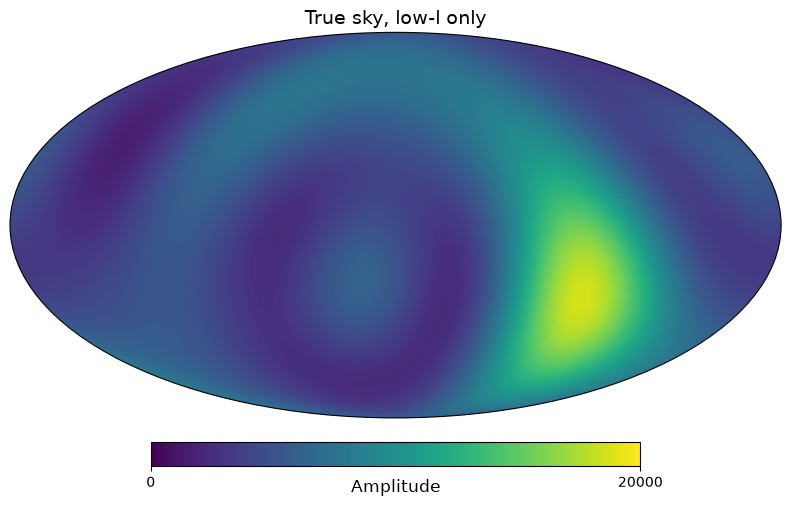

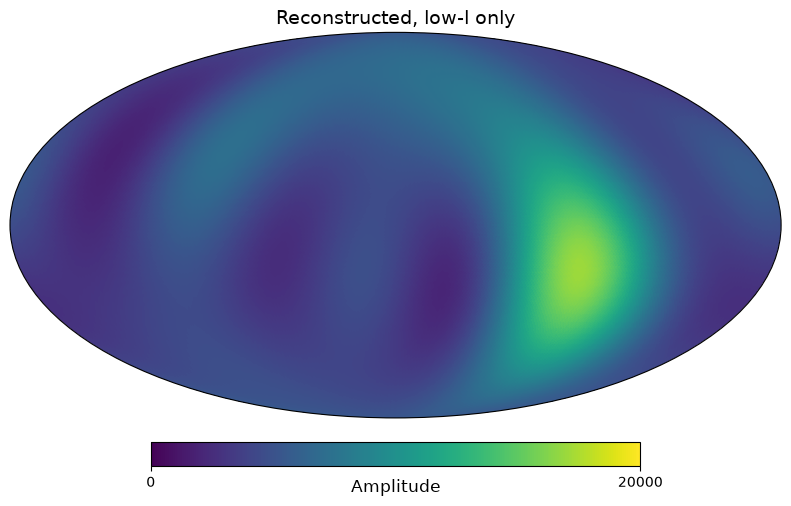

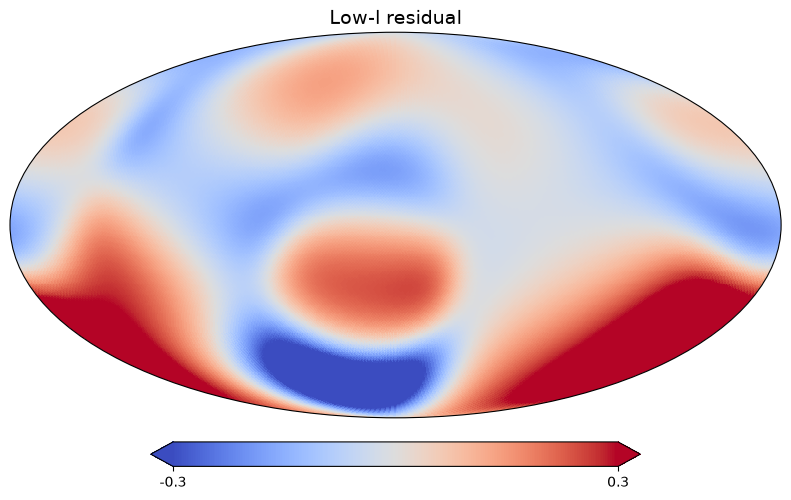

In [23]:
# --- MATCH THE OLD NOTEBOOK'S ACTUAL VALIDATION: LOW-ELL ONLY ---
L_CUTOFF = 5  # matches the old notebook's filtered_true[:5] / [5:]=0

f0 = 0
sky_alm_check = s2fft_unravel(x_sky_single_solve, lmax)  # your single-freq result

filtered_true = np.array(true_sky_alm[f0])
filtered_true[L_CUTOFF:] = 0

filtered_guess = np.array(sky_alm_check[0])
filtered_guess[L_CUTOFF:] = 0

original_skymap_filt = s2fft.inverse_jax(
    filtered_true, L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real
guess_skymap_filt = s2fft.inverse_jax(
    filtered_guess, L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real

original_skymap_filt = np.asarray(original_skymap_filt)
guess_skymap_filt = np.asarray(guess_skymap_filt)

rel_err_filt = 100 * np.sqrt(np.mean((original_skymap_filt - guess_skymap_filt) ** 2)) / np.sqrt(np.mean(original_skymap_filt**2))
print(f"Low-ell-only (l<{L_CUTOFF}) relative error: {rel_err_filt:.2f}%")

hp.projview(original_skymap_filt, title="True sky, low-l only", unit="Amplitude", cbar=True, cmap="viridis", min=0, max=2e4)
plt.show()
hp.projview(guess_skymap_filt, title="Reconstructed, low-l only", unit="Amplitude", cbar=True, cmap="viridis", min=0, max=2e4)
plt.show()
hp.projview((original_skymap_filt - guess_skymap_filt) / original_skymap_filt, title="Low-l residual", min=-0.3, max=0.3, cmap="coolwarm")
plt.show()

Beam channels 2:10  <->  sky channels 1:9
Physical frequencies (vivaldi): [52000000. 53000000. 54000000. 55000000. 56000000. 57000000. 58000000.
 59000000.]

f0=0  (freq=52000000 Hz)  low-l rel_err = 18.44%


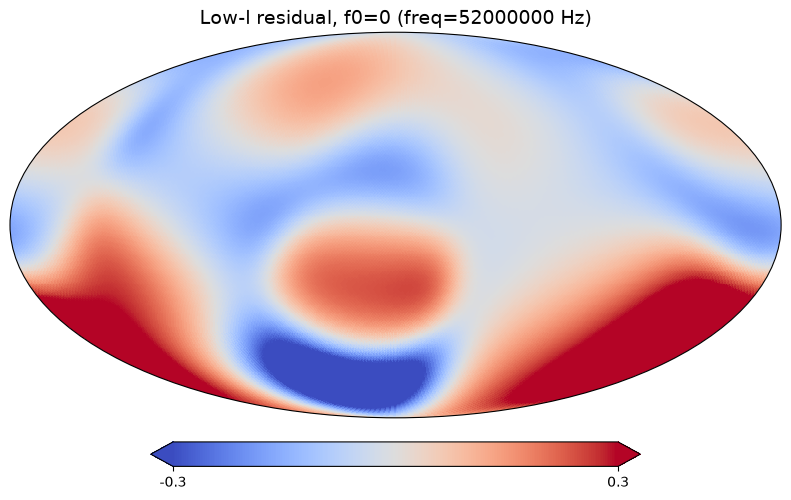

f0=1  (freq=53000000 Hz)  low-l rel_err = 18.46%


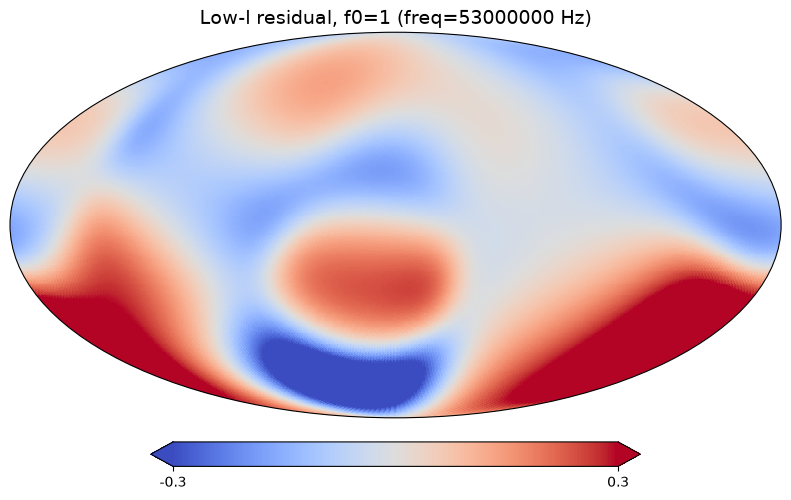

f0=2  (freq=54000000 Hz)  low-l rel_err = 18.47%


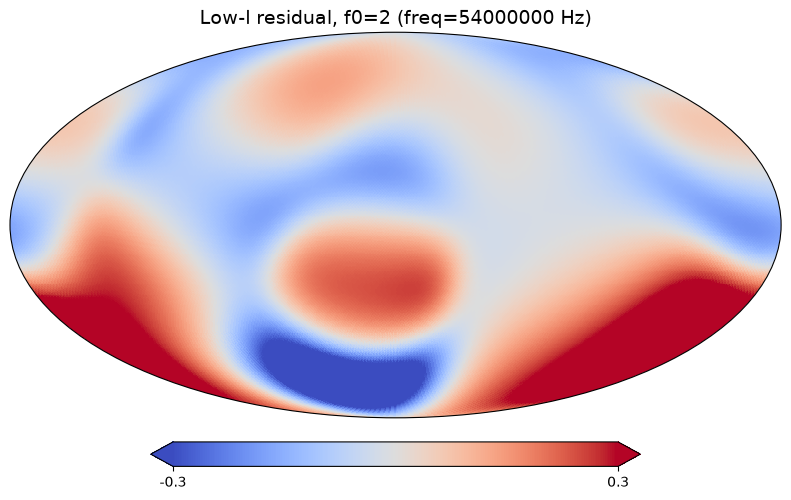

f0=3  (freq=55000000 Hz)  low-l rel_err = 18.47%


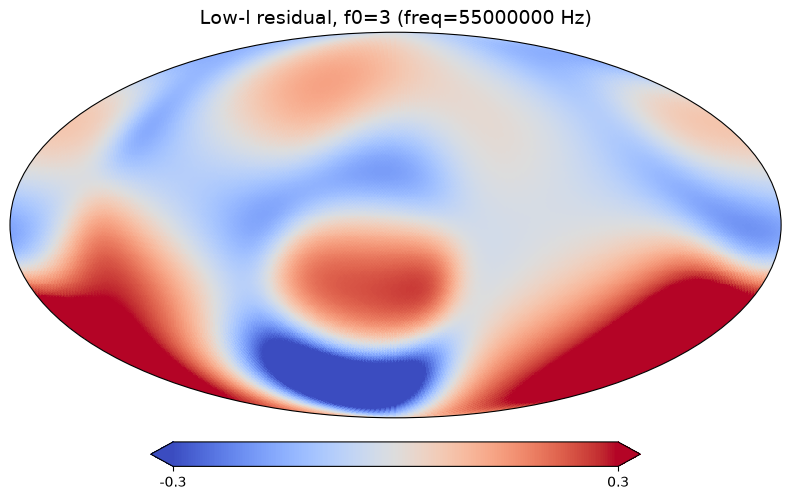

f0=4  (freq=56000000 Hz)  low-l rel_err = 18.48%


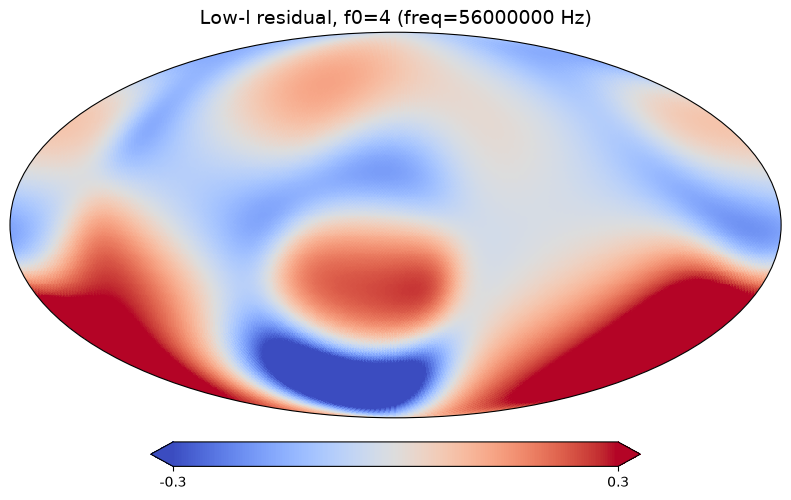

f0=5  (freq=57000000 Hz)  low-l rel_err = 18.46%


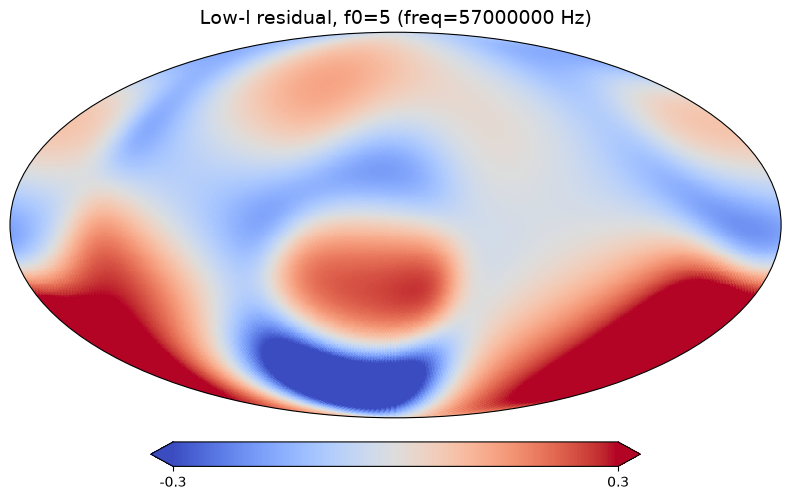

f0=6  (freq=58000000 Hz)  low-l rel_err = 18.45%


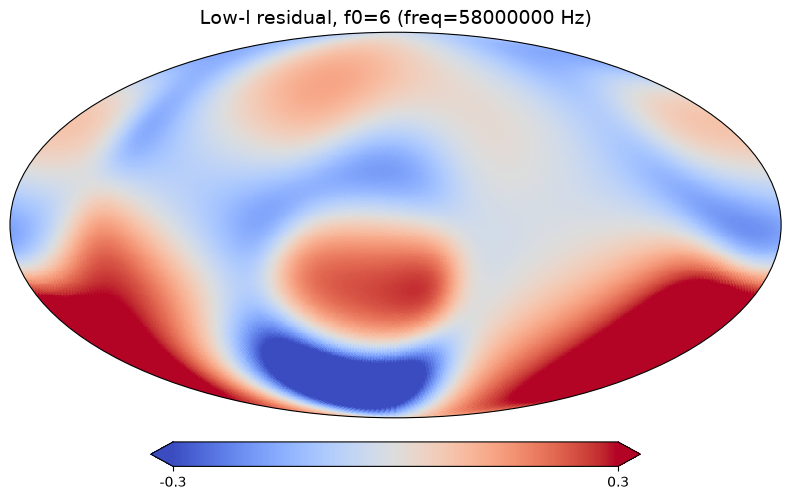

f0=7  (freq=59000000 Hz)  low-l rel_err = 18.43%


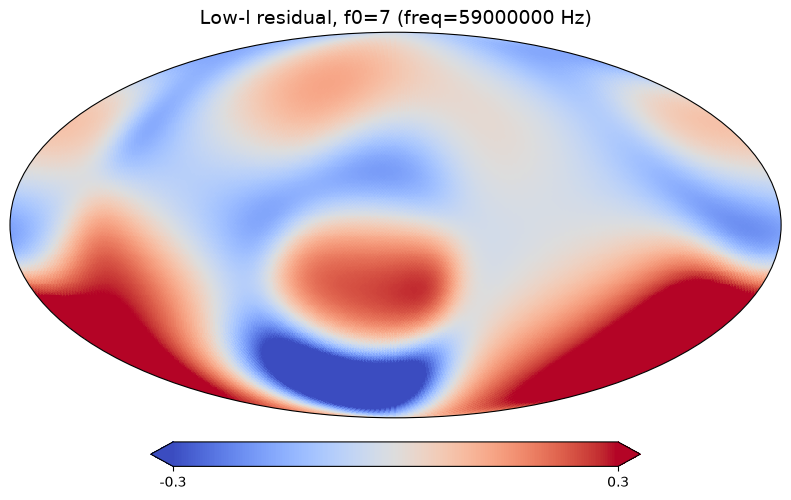

In [24]:
# --- LOW-ELL RESIDUAL, PER FREQUENCY ---
# Same single-frequency-alone solve and low-ell filter as before, looped
# across every channel in the current FREQ_START:FREQ_END range. Each
# solve is independent (no cross-frequency coupling in this model), so
# this is a direct per-channel comparison.

L_CUTOFF = 5

def solve_and_filter_single_freq(f0, tol=1e-6, maxiter=1000):
  y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
  y_single = y_true_3d[f0:f0+1].reshape(-1)

  model_unc_single = 0.0015 * jnp.abs(y_true_3d[f0:f0+1])
  Ndiag_single = (thermal_sigma_fixed**2 + model_unc_single**2).reshape(-1)

  S_diag2_2d = S_diag2.reshape(N_FREQS, -1)
  S_diag2_single = S_diag2_2d[f0]

  beam_true_single = beam_alms_TRUE_transformed[:, f0:f0+1, :, :]
  _x0_single = jnp.zeros(oned_shape)

  def forward_single(x_flat):
    sky_alm_single = s2fft_unravel(x_flat, lmax)
    vis = jnp.einsum(
        "flm,tm,bflm->ftb", sky_alm_single, phases.conjugate(), beam_true_single
    )
    norms_single = compute_norms_curr(beam_true_single)
    return (vis.real / norms_single.T[:, None, :]).ravel()

  _adj_single = jax.linear_transpose(forward_single, _x0_single)

  def matvec_single(a):
    x_sky = S_diag2_single * _adj_single(a)[0]
    return forward_single(x_sky) + Ndiag_single * a

  alpha_sol, _ = jsp_linalg.cg(matvec_single, y_single, tol=tol, maxiter=maxiter)
  x_sky_single_solve = S_diag2_single * _adj_single(alpha_sol)[0]
  sky_alm_check = s2fft_unravel(x_sky_single_solve, lmax)

  filtered_true = np.array(true_sky_alm[f0])
  filtered_true[L_CUTOFF:] = 0
  filtered_guess = np.array(sky_alm_check[0])
  filtered_guess[L_CUTOFF:] = 0

  true_filt = np.asarray(s2fft.inverse_jax(
      filtered_true, L=lmax + 1, spin=0, nside=nside,
      sampling="healpix", reality=True,
  ).real)
  guess_filt = np.asarray(s2fft.inverse_jax(
      filtered_guess, L=lmax + 1, spin=0, nside=nside,
      sampling="healpix", reality=True,
  ).real)

  rel_err = 100 * np.sqrt(np.mean((true_filt - guess_filt) ** 2)) / np.sqrt(np.mean(true_filt**2))
  return true_filt, guess_filt, rel_err


print(f"Beam channels {FREQ_START}:{FREQ_END}  <->  sky channels {FREQ_START-1}:{FREQ_END-1}")
print(f"Physical frequencies (vivaldi): {freq}\n")

for f0 in range(N_FREQS):
  true_filt, guess_filt, rel_err = solve_and_filter_single_freq(f0)
  print(f"f0={f0}  (freq={float(freq[f0]):.0f} Hz)  low-l rel_err = {rel_err:.2f}%")

  residual = (true_filt - guess_filt) / true_filt
  hp.projview(
      residual,
      title=f"Low-l residual, f0={f0} (freq={float(freq[f0]):.0f} Hz)",
      min=-0.3, max=0.3, cmap="coolwarm",
  )
  plt.show()

In [ ]:
# --- REAL POSTERIOR OVER p (fix #1: the original notebook never actually ---
# --- instantiated MCMC/NUTS anywhere) ---
from numpyro.infer import init_to_value


def beam_model(y_obs, base_beam, mode_tensor, fixed_sky, noise_diag):
  n_modes = mode_tensor.shape[0]
  p = numpyro.sample(
      "p", dist.Normal(jnp.zeros(n_modes), 0.1 * jnp.ones(n_modes))
  )
  perturbation = jnp.einsum("k, kbf... -> bf...", p, mode_tensor)
  beam_curr = base_beam + perturbation
  norms_curr = compute_norms_curr(beam_curr)

  sky_alm_multi = s2fft_unravel(fixed_sky, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_curr
  )
  y_pred = (vis.real / norms_curr.T[:, None, :]).ravel()

  numpyro.sample("obs", dist.Normal(y_pred, jnp.sqrt(noise_diag)), obs=y_obs)


nuts_kernel = NUTS(
    beam_model,
    init_strategy=init_to_value(values={"p": p_joint}),
    dense_mass=True,
)
mcmc = MCMC(nuts_kernel, num_warmup=300, num_samples=500, num_chains=1)

print("Running NUTS on the beam-error coefficients (fixed sky = x_sky_pos)...")
mcmc.run(
    jax.random.PRNGKey(0),
    y_obs=y_true,
    base_beam=beam_alms_PERTURBED_transformed,
    mode_tensor=mode_tensor,
    fixed_sky=x_sky_pos,
    noise_diag=Ndiag,
)
mcmc.print_summary()

mcmc_samples = mcmc.get_samples()
mean_p = jnp.mean(mcmc_samples["p"], axis=0)
std_p = jnp.std(mcmc_samples["p"], axis=0)
print(f"\nLBFGS point estimate : {p_joint}")
print(f"NUTS posterior mean   : {mean_p}")
print(f"NUTS posterior std    : {std_p}")
print(f"Oracle (lstsq)         : {p_best_fit}")

best_perturbation = jnp.einsum("k, kbf... -> bf...", mean_p, mode_tensor)
best_beam = beam_alms_PERTURBED_transformed + best_perturbation
_norms_best_beam = compute_norms_curr(best_beam)


def forward_calibrated_model(x_flat):
  sky_alm_multi = s2fft_unravel(x_flat, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), best_beam
  )
  return (vis.real / _norms_best_beam.T[:, None, :]).ravel()


_adj_calibrated = jax.linear_transpose(forward_calibrated_model, _x0_multi)


def adjoint_calibrated(y_flat):
  return _adj_calibrated(y_flat)[0]


def matvec_final(alpha):
  x_sky = S_diag2 * adjoint_calibrated(alpha)
  return forward_calibrated_model(x_sky) + Ndiag * alpha


alpha_final, _ = jsp_linalg.cg(matvec_final, y_true, tol=1e-5, maxiter=200)
x_wiener_cal_raw = S_diag2 * adjoint_calibrated(alpha_final)

sky_alm_multi_cal = s2fft_unravel(x_wiener_cal_raw, lmax)
sky_alm_pos_list = []
for f in range(N_FREQS):
  m = s2fft.inverse_jax(
      sky_alm_multi_cal[f], L=lmax + 1, spin=0, nside=nside,
      sampling="healpix", reality=True,
  ).real
  m_pos = jnp.maximum(m, 0.0)
  alm_pos = s2fft.forward_jax(
      m_pos, L=lmax + 1, spin=0, nside=nside, sampling="healpix", reality=True
  )
  sky_alm_pos_list.append(alm_pos)

m_wiener_calibrated = s2fft_ravel(jnp.stack(sky_alm_pos_list))


In [ ]:
# --- TEST: IS THE POSITIVITY CLIP STILL ABSORBING SIGNAL (fix #4), NOW ---
# --- THAT BASIS/NORMALIZATION/PRIOR (fixes #1-3) ARE CORRECTED? ---
nuts_kernel_raw = NUTS(
    beam_model,
    init_strategy=init_to_value(values={"p": p_joint}),
    dense_mass=True,
)
mcmc_raw = MCMC(nuts_kernel_raw, num_warmup=300, num_samples=500, num_chains=1)

print("Running NUTS (fixed sky = x_raw_final, UNCLIPPED)...")
mcmc_raw.run(
    jax.random.PRNGKey(0),
    y_obs=y_true,
    base_beam=beam_alms_PERTURBED_transformed,
    mode_tensor=mode_tensor,
    fixed_sky=x_raw_final,
    noise_diag=Ndiag,
)
mcmc_raw.print_summary()

samples_raw = mcmc_raw.get_samples()
mean_p_raw = jnp.mean(samples_raw["p"], axis=0)
std_p_raw = jnp.std(samples_raw["p"], axis=0)

print(f"\n--- Comparison ---")
print(f"Oracle (lstsq, corrected basis) : {p_best_fit}")
print(f"Clipped-sky (x_sky_pos) mean     : {mean_p}")
print(f"Raw-sky (x_raw_final) mean       : {mean_p_raw}")
print(f"Raw-sky posterior std            : {std_p_raw}")
print(
    "Result from this session: raw-sky and clipped-sky means came out "
    "essentially identical for modes 0-2, ruling OUT the positivity clip "
    "as the explanation for those modes staying near zero - see the "
    "mode-degeneracy diagnostic below for what actually explains it."
)


In [ ]:
# --- DIAGNOSTIC: ARE MODES 0-2 NEARLY DEGENERATE WITH EACH OTHER? ---
# Modes 0-2 stayed near zero (or wrong-signed) across every fit method
# above, DESPITE having the highest raw visibility sensitivity of all 5
# modes - the opposite of what "not enough signal" would predict. That
# pattern points to near-degeneracy AMONG the modes themselves: if their
# visibility signatures are nearly parallel, the likelihood forms a long,
# curved ridge that doesn't align with any single coordinate axis, and
# point estimates / samplers can get stuck near the ridge's centroid.

def vis_from_p(p, fixed_sky):
  perturbation = jnp.einsum("k, kbf... -> bf...", p, mode_tensor)
  beam_curr = beam_alms_PERTURBED_transformed + perturbation
  norms_curr = compute_norms_curr(beam_curr)
  sky_alm_multi = s2fft_unravel(fixed_sky, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_curr
  )
  return (vis.real / norms_curr.T[:, None, :]).ravel()


jac_modes = jax.jacfwd(lambda p: vis_from_p(p, cheat_sky_flat))(jnp.zeros(N_MODES))
mode_norms = jnp.linalg.norm(jac_modes, axis=0)
print("Per-mode visibility sensitivity (||d(vis)/dp_k||):")
print(mode_norms)

gram = jac_modes.T @ jac_modes  # UNWEIGHTED Gram matrix (no 1/Ndiag yet -
                                 # see the whitening cell below, which uses
                                 # the properly noise-weighted version)
norms_outer = jnp.outer(mode_norms, mode_norms)
corr_matrix = gram / (norms_outer + 1e-12)

print("\nPairwise cosine similarity between modes' visibility signatures:")
print(np.array(corr_matrix))

eigvals = jnp.linalg.eigvalsh(gram)
print(f"\nEigenvalues of the (unweighted) mode Gram matrix:")
print(eigvals)
print(f"Condition number: {eigvals[-1]/eigvals[0]:.2e}")


In [ ]:
# --- FIX #7 CHECK: DOES MULTI-FREQUENCY DATA ACTUALLY IMPROVE CONDITIONING? ---
# Same Gram-matrix diagnostic as the cell above, but now jac_modes/mode_norms
# will naturally span every frequency in [FREQ_START, FREQ_END) if that was
# widened above and all setup cells were rerun. Compare the cosine
# similarities and condition number here against the single-frequency
# result (mode 0/1 at -0.9462, condition number 5.4e3) to see whether
# frequency diversity is actually breaking the degeneracy, not just
# assumed to.

print(f"Using {N_FREQS} frequency channel(s): indices {FREQ_START} to {FREQ_END-1}")

jac_modes_mf = jax.jacfwd(lambda p: vis_from_p(p, cheat_sky_flat))(jnp.zeros(N_MODES))
mode_norms_mf = jnp.linalg.norm(jac_modes_mf, axis=0)
print("\nPer-mode visibility sensitivity (all frequencies combined):")
print(mode_norms_mf)

gram_mf = jac_modes_mf.T @ jac_modes_mf
norms_outer_mf = jnp.outer(mode_norms_mf, mode_norms_mf)
corr_matrix_mf = gram_mf / (norms_outer_mf + 1e-12)

print("\nPairwise cosine similarity between modes (multi-frequency):")
print(np.array(corr_matrix_mf))

eigvals_mf = jnp.linalg.eigvalsh(gram_mf)
print(f"\nEigenvalues of the (unweighted) mode Gram matrix (multi-frequency):")
print(eigvals_mf)
print(f"Condition number: {eigvals_mf[-1]/eigvals_mf[0]:.2e}")
print(
    "\nCompare to the single-frequency result above (mode 0/1 correlation "
    "-0.9462, condition number 5.4e3). A meaningfully lower condition "
    "number and lower |correlation| here would confirm frequency diversity "
    "is genuinely helping disambiguate the modes, not just theoretically "
    "expected to."
)


In [ ]:
# --- FIX #5: ROTATE *AND* WHITEN, using the noise-weighted Fisher matrix ---
# A first attempt rotated into the (unweighted) Gram matrix's eigenbasis
# without whitening - this made things WORSE (0.05x "improvement", i.e.
# 20x worse than baseline), because the eigenvalues still spanned ~5,400x
# in scale even after rotation, and LBFGS's step-size heuristics aren't
# built for that. This version divides by sqrt(eigenvalue) too (proper
# PCA whitening), and uses the NOISE-WEIGHTED Fisher matrix (1/Ndiag),
# which is the actual curvature of chi2, not the earlier unweighted Gram
# matrix from the diagnostic cell above.

Ndiag_sqrt = jnp.sqrt(Ndiag)
jac_weighted = jac_modes / Ndiag_sqrt[:, None]        # matches actual chi2 curvature
fisher = jac_weighted.T @ jac_weighted                 # true Hessian of chi2 at p=0

fisher_eigvals, fisher_eigvecs = jnp.linalg.eigh(fisher)
fisher_eigvals = fisher_eigvals[::-1]
Vf = fisher_eigvecs[:, ::-1]
print("Noise-weighted Fisher eigenvalues (descending = best-constrained first):")
print(fisher_eigvals)

sqrt_eig = jnp.sqrt(jnp.clip(fisher_eigvals, 1e-8, None))
mode_tensor_rot = jnp.einsum("kbf..., kj -> jbf...", mode_tensor, Vf)
mode_tensor_white = mode_tensor_rot / sqrt_eig[:, None, None, None, None]

r_best_fit = sqrt_eig * (Vf.T @ p_best_fit)
print(f"\nOracle in whitened r-basis: {r_best_fit}")
print(
    "(components near O(1) are well-constrained by the data relative to "
    "typical noise; components near 0 given their scale are honestly "
    "weakly-constrained by this data - that is expected, not a bug.)"
)

# --- FREE SANITY CHECK: does the transform actually round-trip? ---
# Pure linear algebra - no s2fft, no LBFGS - should take milliseconds.
# Run and check this BEFORE the fit cell below, especially on a freshly
# restarted kernel: this tells you whether the transform itself is
# correct, independent of any solver behavior or memory issues.
p_roundtrip = Vf @ (r_best_fit / sqrt_eig)
roundtrip_err = jnp.max(jnp.abs(p_roundtrip - p_best_fit))
print(f"\nRound-trip error (should be ~1e-6 or smaller): {roundtrip_err:.2e}")

pert_via_p = jnp.einsum("k, kbf... -> bf...", p_best_fit, mode_tensor)
pert_via_r = jnp.einsum("k, kbf... -> bf...", r_best_fit, mode_tensor_white)
consistency_err = jnp.max(jnp.abs(pert_via_p - pert_via_r)) / jnp.max(jnp.abs(pert_via_p))
print(f"Relative perturbation-reconstruction error (should be ~1e-5 or smaller): {consistency_err:.2e}")

if roundtrip_err > 1e-3 or consistency_err > 1e-3:
  print("STOP: the whitening transform itself has a bug - fix this before running the fit cell below.")
else:
  print("Transform verified consistent - safe to proceed to the LBFGS fit below.")


In [ ]:
# --- FIT IN THE WHITENED r-BASIS ---
# UNVALIDATED as of this notebook version: the kernel crashed during this
# cell in the debugging session, before any output printed. Run the
# sanity-check cell above FIRST (cheap, no s2fft) on a freshly restarted
# kernel and confirm both errors are small before running this.

def _beam_loss_r(r, x_constrained, prior_sigma):
  perturbation = jnp.einsum("k, kbf... -> bf...", r, mode_tensor_white)
  beam_curr = beam_alms_PERTURBED_transformed + perturbation
  norms_curr = compute_norms_curr(beam_curr)
  sky_alm_multi = s2fft_unravel(x_constrained, lmax)
  vis = jnp.einsum(
      "flm,tm,bflm->ftb", sky_alm_multi, phases.conjugate(), beam_curr
  )
  y_pred = (vis.real / norms_curr.T[:, None, :]).ravel()
  res = (y_true - y_pred) / jnp.sqrt(Ndiag)
  chi2 = 0.5 * jnp.sum(res**2)
  prior = 0.5 * jnp.sum((r / prior_sigma) ** 2)  # prior_sigma in "Fisher units" now
  return chi2 + prior


_lbfgs_r = jaxopt.LBFGS(fun=_beam_loss_r, maxiter=200, tol=1e-6)
res_r = _lbfgs_r.run(jnp.zeros(N_MODES), cheat_sky_flat, 1.0)
r_lbfgs = res_r.params

print(f"Oracle (r-basis) : {r_best_fit}")
print(f"LBFGS  (r-basis) : {r_lbfgs}")

p_from_r = Vf @ (r_lbfgs / sqrt_eig)
print(f"\nOracle (p-basis)   : {p_best_fit}")
print(f"Recovered (p-basis) : {p_from_r}")

perturbation_r = jnp.einsum("k, kbf... -> bf...", p_from_r, mode_tensor)
best_beam_r = beam_alms_PERTURBED_transformed + perturbation_r
best_beam_r_pixel = s2fft.inverse_jax(
    best_beam_r[0, 0], L=lmax + 1, spin=0, nside=nside,
    sampling="healpix", reality=True,
).real
best_fit_map_r = np.asarray(best_beam_r_pixel)

post_rmse_r = np.sqrt(np.mean((best_fit_map_r - true_map)**2))
pre_rmse = np.sqrt(np.mean((pert_map - true_map)**2))
true_rms = np.sqrt(np.mean(true_map**2))
print(f"\nPre-calibration relative error : {100*pre_rmse/true_rms:.2f}%")
print(f"Whitened r-basis relative error : {100*post_rmse_r/true_rms:.4f}%")
print(f"RMSE improvement factor         : {pre_rmse/post_rmse_r:.2f}x")


In [14]:
# --- CORRECTED ADJOINT CONSISTENCY TEST ---
n_sky_alms = N_FREQS * oned_shape
visibility_shape = y_true.shape

key = jax.random.PRNGKey(123)
key1, key2 = jax.random.split(key)

# MUST BE REAL VECTOR (packed ALM representation)
x_dummy = jax.random.normal(key1, shape=(n_sky_alms,), dtype=jnp.float64)
y_dummy = jax.random.normal(key2, shape=visibility_shape, dtype=jnp.float64)

Ax = forward_calibrated_model(x_dummy)
A_adj_y = adjoint_calibrated(y_dummy)

dot1 = jnp.vdot(Ax, y_dummy).real
dot2 = jnp.vdot(x_dummy, A_adj_y).real

ratio = dot1 / dot2

print(f"<A_cal x, y>    = {dot1:.6e}")
print(f"<x, A_cal^T y> = {dot2:.6e}")
print(f"Adjoint Ratio   = {ratio:.6e}")

<A_cal x, y>    = -7.594502e+01
<x, A_cal^T y> = -7.594502e+01
Adjoint Ratio   = 1.000000e+00


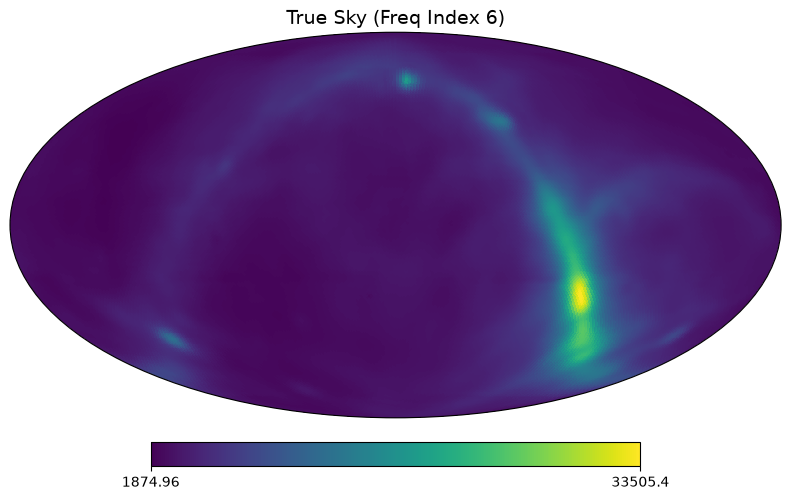

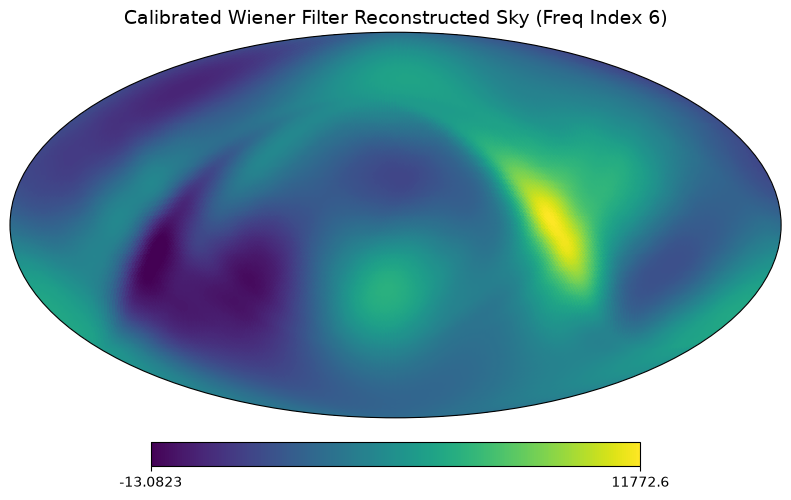

In [15]:
# --- VISUALIZE CALIBRATED RECONSTRUCTED SKY VS TRUE SKY ---
sky_calibrated_alm = s2fft_unravel(m_wiener_calibrated, lmax)
f_idx = 0

original_skymap_0 = s2fft.inverse_jax(
    true_sky_alm[f_idx],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real

calibrated_skymap_0 = s2fft.inverse_jax(
    sky_calibrated_alm[f_idx],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real

hp.projview(
    original_skymap_0, title=f"True Sky (Freq Index {FREQ_START + f_idx})"
)
plt.show()

hp.projview(
    calibrated_skymap_0,
    title=(
        "Calibrated Wiener Filter Reconstructed Sky (Freq Index"
        f" {FREQ_START + f_idx})"
    ),
)
plt.show()

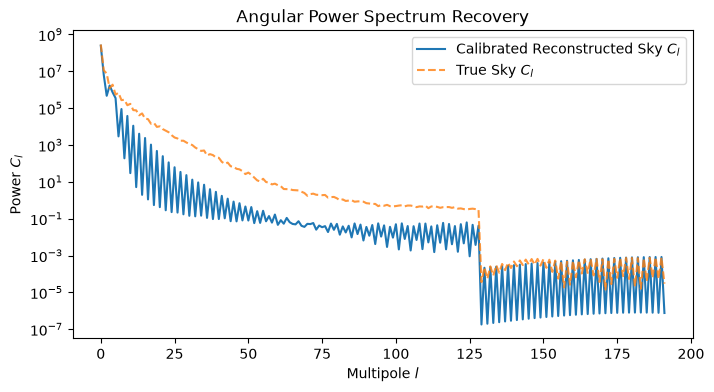

In [16]:
# --- ANGULAR POWER SPECTRUM COMPARISON ---
original_skymap_0 = np.asarray(original_skymap_0, dtype=np.float64)
power_spectrum_orig = hp.sphtfunc.anafast(original_skymap_0)
power_spectrum_calibrated = hp.sphtfunc.anafast(
    np.asarray(calibrated_skymap_0, dtype=np.float64)
)

plt.figure(figsize=(8, 4))
plt.semilogy(
    power_spectrum_calibrated, label="Calibrated Reconstructed Sky $C_l$"
)
plt.semilogy(
    power_spectrum_orig, label="True Sky $C_l$", linestyle="--", alpha=0.8
)
plt.xlabel("Multipole $l$")
plt.ylabel("Power $C_l$")
plt.title("Angular Power Spectrum Recovery")
plt.legend()
plt.show()

||y_true||        : 452706.92829001334
||y_guess_best||  : 452720.0907401337
Relative Vis Error : 0.000846942018879907


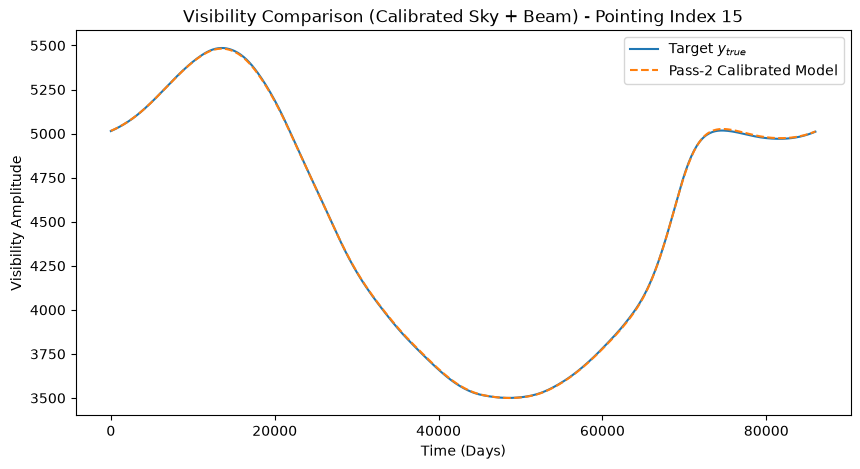

In [17]:
# --- VISIBILITY COMPARISON (CALIBRATED SKY + CALIBRATED BEAM) ---
y_guess_best = forward_calibrated_model(m_wiener_calibrated)

print("||y_true||        :", float(jnp.linalg.norm(y_true)))
print("||y_guess_best||  :", float(jnp.linalg.norm(y_guess_best)))
print(
    "Relative Vis Error :",
    float(
        jnp.linalg.norm(y_guess_best - y_true) / jnp.linalg.norm(y_true)
    ),
)

y_true_3d = y_true.reshape(N_FREQS, ntimes, total_beam_num)
y_guess_3d = y_guess_best.reshape(N_FREQS, ntimes, total_beam_num)

b_idx = 15

plt.figure(figsize=(10, 5))
true_plot = y_true_3d[0]
guess_plot = y_guess_3d[0]

plt.plot(
    times_jd - times_jd[0], true_plot[:, b_idx], label="Target $y_{true}$"
)
plt.plot(
    times_jd - times_jd[0],
    guess_plot[:, b_idx],
    ls="--",
    label="Pass-2 Calibrated Model",
)

plt.title(
    "Visibility Comparison (Calibrated Sky + Beam) - Pointing Index"
    f" {b_idx}"
)
plt.xlabel("Time (Days)")
plt.ylabel("Visibility Amplitude")
plt.legend()
plt.show()

--- Visualizing MCMC Calibration Success ---


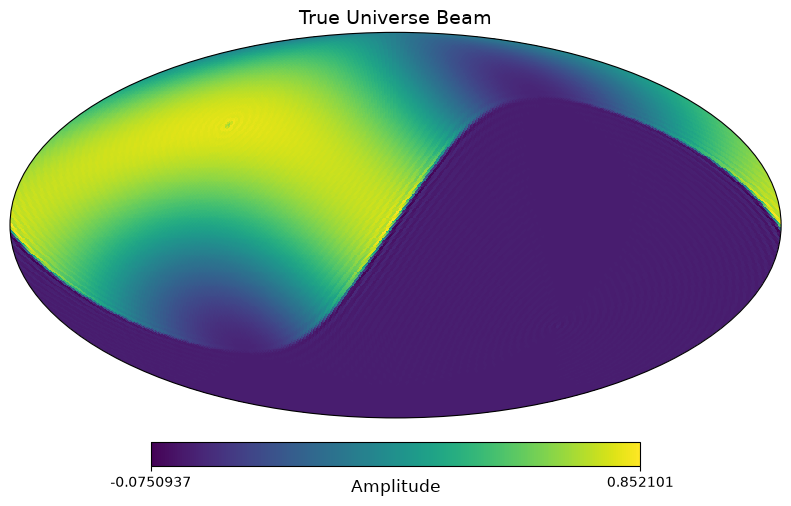

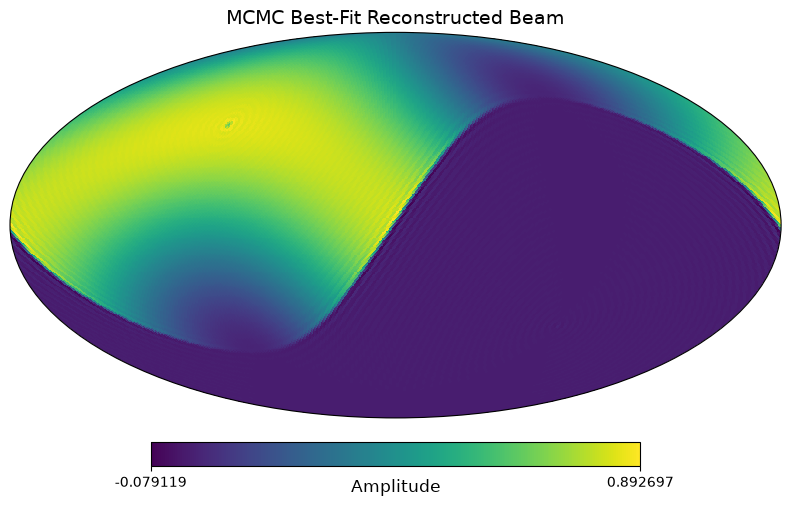

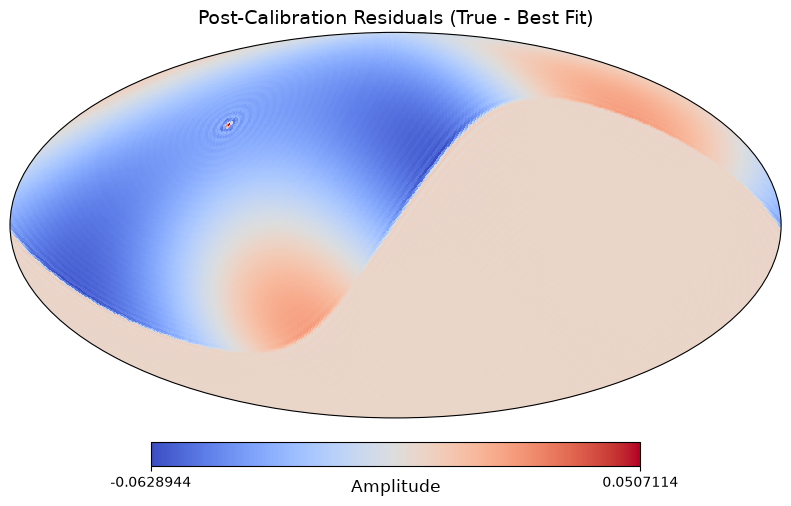

In [18]:
# --- VISUALIZE SPATIAL BEAM RECONSTRUCTION RESIDUALS ---
b_idx = 0
f_idx = 0

true_beam_pixel = s2fft.inverse_jax(
    beam_alms_TRUE_transformed[b_idx, f_idx],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real
true_map = np.asarray(true_beam_pixel)

best_beam_pixel = s2fft.inverse_jax(
    best_beam[b_idx, f_idx],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real
best_fit_map = np.asarray(best_beam_pixel)

final_residuals = true_map - best_fit_map

print("--- Visualizing MCMC Calibration Success ---")

hp.projview(
    true_map,
    title="True Universe Beam",
    unit="Amplitude",
    cbar=True,
    cmap="viridis",
)
plt.show()

hp.projview(
    best_fit_map,
    title="MCMC Best-Fit Reconstructed Beam",
    unit="Amplitude",
    cbar=True,
    cmap="viridis",
)
plt.show()

hp.projview(
    final_residuals,
    title="Post-Calibration Residuals (True - Best Fit)",
    unit="Amplitude",
    cbar=True,
    cmap="coolwarm",
)
plt.show()

In [19]:
# --- GLOBAL QUANTITATIVE ERROR METRICS & CHEAT SANITY CHECK ---
pre_res = pert_map - true_map
post_res = best_fit_map - true_map

pre_mae = np.mean(np.abs(pre_res))
post_mae = np.mean(np.abs(post_res))

pre_rmse = np.sqrt(np.mean(pre_res**2))
post_rmse = np.sqrt(np.mean(post_res**2))

true_rms = np.sqrt(np.mean(true_map**2))
pre_rel = (pre_rmse / true_rms) * 100
post_rel = (post_rmse / true_rms) * 100

rmse_improvement = pre_rmse / post_rmse
mae_improvement = pre_mae / post_mae

print("==========================================================")
print("            GLOBAL BEAM ERROR ANALYSIS                  ")
print("==========================================================")
print("Metric              | Pre-Calibration | Post-MCMC Calibration")
print("--------------------|-----------------|----------------------")
print(f"Mean Absolute Error | {pre_mae:15.2f} | {post_mae:20.2f}")
print(f"Root Mean Square    | {pre_rmse:15.2f} | {post_rmse:20.2f}")
print(f"Relative Beam Error | {pre_rel:14.2f}% | {post_rel:19.4f}%")
print("----------------------------------------------------------")
print(
    "Overall RMSE Improvement Factor:"
    f" {rmse_improvement:.1f}x reduction in error."
)
print("==========================================================")

print("\nStarting Sanity Check MCMC (Using TRUE Sky)...")

cheat_sky_flat = s2fft_ravel(true_sky_alm)

mcmc.run(
    jax.random.PRNGKey(42),
    y_obs=y_true,
    base_beam=beam_alms_PERTURBED_transformed,
    mode_tensor=mode_tensor,
    fixed_sky=cheat_sky_flat,
    noise_diag=Ndiag,
)

mcmc_samples_cheat = mcmc.get_samples()
mean_p_cheat = jnp.mean(mcmc_samples_cheat["p"], axis=0)
print(f"Mean PCA parameters found with True Sky: {mean_p_cheat}")

            GLOBAL BEAM ERROR ANALYSIS                  
Metric              | Pre-Calibration | Post-MCMC Calibration
--------------------|-----------------|----------------------
Mean Absolute Error |            0.01 |                 0.01
Root Mean Square    |            0.02 |                 0.02
Relative Beam Error |           5.63% |              5.6330%
----------------------------------------------------------
Overall RMSE Improvement Factor: 1.0x reduction in error.

Starting Sanity Check MCMC (Using TRUE Sky)...


NameError: name 'mcmc' is not defined